# Brain Tumor MRI Classification & Explainable AI

## Phase 0 — Project Setup

### Project Scope

This project classifies brain MRI images into four predefined categories:

1. No Tumor
2. Glioma
3. Meningioma
4. Pituitary Tumor

### Disclaimer

This is an educational/research prototype and is NOT a clinical diagnostic system.

Model confidence must not be interpreted as:
- cancer probability
- tumor percentage
- medical certainty
- a medical diagnosis

### Environment

- Google Colab
- Google Drive
- PyTorch
- EfficientNet-B0

PHASE 0 STARTS

In [ ]:
# Colab setup
%pip install -q ImageHash seaborn tqdm

from google.colab import drive

drive.mount('/content/drive')

import os
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Colab setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.2 MB/s eta 0:00:00
Mounted at /content/drive
Colab setup complete.


In [ ]:
# Phase 0 Cell 3: Check CUDA availability
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available")

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/BrainTumorProject"

print("Project directory exists:", os.path.exists(BASE_DIR))
print("\nContents:")

for item in sorted(os.listdir(BASE_DIR)):
    print("📁", item)

Project directory exists: True

Contents:
📁 dataset
📁 logs
📁 models
📁 notebooks
📁 results


In [ ]:
import platform
import torch
import torchvision
import sklearn
import matplotlib
import pandas

print("===== SYSTEM =====")
print("Python:", platform.python_version())
print("OS:", platform.system())

print("\n===== PYTORCH =====")
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

print("\n===== OTHER LIBRARIES =====")
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Pandas:", pandas.__version__)

===== SYSTEM =====
Python: 3.13.15
OS: Linux

===== PYTORCH =====
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA: 12.8

===== OTHER LIBRARIES =====
Scikit-learn: 1.6.1
Matplotlib: 3.10.0
Pandas: 2.2.3


In [ ]:
# Phase 0 Cell 7: Define centralized project configuration and infrastructure helpers
import os
import torch
from pathlib import Path

# ============================================================
# SHARED INFRASTRUCTURE - USED BY ALL PHASES
# ============================================================

def setup_drive_and_paths():
    """
    Robust Google Drive setup and centralized path configuration.
    This function can be called by any phase to ensure proper initialization.
    """
    # Mount Drive if not already mounted
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive'):
            drive.mount('/content/drive')
            print("Google Drive mounted successfully.")
        else:
            print("Google Drive already mounted.")
    except ImportError:
        print("Not running in Google Colab - Drive mounting skipped.")
    
    # Centralized project root
    PROJECT_ROOT = Path("/content/drive/MyDrive/BrainTumorProject")
    
    # Validate project root exists
    if not PROJECT_ROOT.exists():
        raise FileNotFoundError(
            f"Project root not found: {PROJECT_ROOT}\n"
            "Please ensure the BrainTumorProject directory exists in Google Drive."
        )
    
    # Centralized path configuration
    paths = {
        'PROJECT_ROOT': PROJECT_ROOT,
        'DATASET_DIR': PROJECT_ROOT / "dataset",
        'MODEL_DIR': PROJECT_ROOT / "models",
        'RESULTS_DIR': PROJECT_ROOT / "results",
        'LOGS_DIR': PROJECT_ROOT / "logs",
    }
    
    # Create directories that should exist dynamically
    for path_name in ['MODEL_DIR', 'RESULTS_DIR', 'LOGS_DIR']:
        paths[path_name].mkdir(parents=True, exist_ok=True)
    
    return paths

def get_device():
    """Get the appropriate device for computation."""
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_class_configuration():
    """
    Returns standardized class configuration used across all phases.
    """
    CLASS_NAMES = [
        "No Tumor",
        "Glioma", 
        "Meningioma",
        "Pituitary Tumor"
    ]
    
    CLASS_MAPPING = {
        "notumor": 0,
        "glioma": 1,
        "meningioma": 2,
        "pituitary": 3
    }
    
    NUM_CLASSES = len(CLASS_NAMES)
    
    return {
        'CLASS_NAMES': CLASS_NAMES,
        'CLASS_MAPPING': CLASS_MAPPING,
        'NUM_CLASSES': NUM_CLASSES
    }

def set_seed(seed=42):
    """Set random seed for reproducibility."""
    import random
    import numpy as np
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def check_required_file(file_path, description="Required file"):
    """
    Check if a required file exists and raise a descriptive error if not.
    """
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"{description} not found: {file_path}\n"
            f"Please ensure the file exists in the expected location."
        )
    return True

def check_required_directory(dir_path, description="Required directory"):
    """
    Check if a required directory exists and raise a descriptive error if not.
    """
    if not Path(dir_path).exists():
        raise FileNotFoundError(
            f"{description} not found: {dir_path}\n"
            f"Please ensure the directory exists in the expected location."
        )
    return True

# ============================================================
# INITIALIZE SHARED CONFIGURATION
# ============================================================

# Initialize paths
PATHS = setup_drive_and_paths()

# Initialize device
DEVICE = get_device()

# Initialize class configuration
CLASS_CONFIG = get_class_configuration()
CLASS_NAMES = CLASS_CONFIG['CLASS_NAMES']
CLASS_MAPPING = CLASS_CONFIG['CLASS_MAPPING']
NUM_CLASSES = CLASS_CONFIG['NUM_CLASSES']

# Set random seed
SEED = 42
set_seed(SEED)

# Assign to individual variables for backward compatibility
BASE_DIR = str(PATHS['PROJECT_ROOT'])
DATASET_DIR = str(PATHS['DATASET_DIR'])
MODEL_DIR = PATHS['MODEL_DIR']
RESULTS_DIR = PATHS['RESULTS_DIR']
LOGS_DIR = PATHS['LOGS_DIR']

# Display configuration
print("=" * 60)
print("CENTRALIZED PROJECT CONFIGURATION")
print("=" * 60)
print(f"Project Root : {PATHS['PROJECT_ROOT']}")
print(f"Dataset      : {PATHS['DATASET_DIR']}")
print(f"Models       : {PATHS['MODEL_DIR']}")
print(f"Results      : {PATHS['RESULTS_DIR']}")
print(f"Logs         : {PATHS['LOGS_DIR']}")
print(f"Device       : {DEVICE}")
print(f"Seed         : {SEED}")
print(f"Classes      : {NUM_CLASSES}")
print("=" * 60)
print("Class Names:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")
print("=" * 60)

In [ ]:
# Phase 0 Cell 8: Verify project structure and save configuration
import os

print("=" * 60)
print("PROJECT STRUCTURE VERIFICATION")
print("=" * 60)

# Verify project root
print(f"\nProject root exists: {PATHS['PROJECT_ROOT'].exists()}")

# Verify expected directories
print(f"\nExpected directories:")
for path_name, path_obj in PATHS.items():
    exists = "✓" if path_obj.exists() else "✗"
    print(f"  {exists} {path_name}: {path_obj}")

# Verify dataset structure
dataset_dir = PATHS['DATASET_DIR']
if dataset_dir.exists():
    print(f"\nDataset contents:")
    for item in sorted(dataset_dir.iterdir()):
        if item.is_dir():
            print(f"  📁 {item.name}")
else:
    print(f"\n⚠ Dataset directory not found: {dataset_dir}")

print("\n" + "=" * 60)
print("SHARED CONFIGURATION SAVED")
print("=" * 60)
print("All phases can now use the centralized configuration:")
print("- setup_drive_and_paths()")
print("- get_device()")
print("- get_class_configuration()")
print("- set_seed()")
print("- check_required_file()")
print("- check_required_directory()")
print("=" * 60)

PHASE 1 STARTS

In [ ]:
import os

NICKPARVAR_DIR = os.path.join(DATASET_DIR, "NickParvar")

print("Dataset path:")
print(NICKPARVAR_DIR)

print("\nContents:")
for item in os.listdir(NICKPARVAR_DIR):
    path = os.path.join(NICKPARVAR_DIR, item)
    print("📁" if os.path.isdir(path) else "📄", item)

Dataset path:
/content/drive/MyDrive/BrainTumorProject/dataset/NickParvar

Contents:
📁 Testing
📁 Training


In [ ]:
# Phase 1 Cell 1: Phase 1 Initialization - Load shared infrastructure
import os
from pathlib import Path

# ============================================================
# PHASE 1 — DATASET EXPLORATION
# ============================================================

print("=" * 60)
print("PHASE 1 — DATASET EXPLORATION INITIALIZATION")
print("=" * 60)

# Initialize shared infrastructure (can be called independently)
# If running independently, we need to define the helper functions
def setup_drive_and_paths():
    """Robust Google Drive setup and centralized path configuration."""
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive'):
            drive.mount('/content/drive')
            print("Google Drive mounted successfully.")
        else:
            print("Google Drive already mounted.")
    except ImportError:
        print("Not running in Google Colab - Drive mounting skipped.")
    
    PROJECT_ROOT = Path("/content/drive/MyDrive/BrainTumorProject")
    
    if not PROJECT_ROOT.exists():
        raise FileNotFoundError(
            f"Project root not found: {PROJECT_ROOT}\n"
            "Please ensure the BrainTumorProject directory exists in Google Drive."
        )
    
    paths = {
        'PROJECT_ROOT': PROJECT_ROOT,
        'DATASET_DIR': PROJECT_ROOT / "dataset",
        'MODEL_DIR': PROJECT_ROOT / "models",
        'RESULTS_DIR': PROJECT_ROOT / "results",
        'LOGS_DIR': PROJECT_ROOT / "logs",
    }
    
    for path_name in ['MODEL_DIR', 'RESULTS_DIR', 'LOGS_DIR']:
        paths[path_name].mkdir(parents=True, exist_ok=True)
    
    return paths

def get_class_configuration():
    """Returns standardized class configuration used across all phases."""
    CLASS_NAMES = [
        "No Tumor",
        "Glioma", 
        "Meningioma",
        "Pituitary Tumor"
    ]
    
    CLASS_MAPPING = {
        "notumor": 0,
        "glioma": 1,
        "meningioma": 2,
        "pituitary": 3
    }
    
    NUM_CLASSES = len(CLASS_NAMES)
    
    return {
        'CLASS_NAMES': CLASS_NAMES,
        'CLASS_MAPPING': CLASS_MAPPING,
        'NUM_CLASSES': NUM_CLASSES
    }

# Initialize paths
PATHS = setup_drive_and_paths()

# Initialize class configuration
CLASS_CONFIG = get_class_configuration()
CLASS_NAMES = CLASS_CONFIG['CLASS_NAMES']
CLASS_MAPPING = CLASS_CONFIG['CLASS_MAPPING']
NUM_CLASSES = CLASS_CONFIG['NUM_CLASSES']

# Define dataset-specific paths
DATASET_DIR = PATHS['DATASET_DIR']
RESULTS_DIR = PATHS['RESULTS_DIR']
NICKPARVAR_DIR = DATASET_DIR / "NickParvar"

# Verify dataset directory exists
if not NICKPARVAR_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory not found: {NICKPARVAR_DIR}\n"
        "Please ensure the NickParvar dataset exists in the dataset folder."
    )

print(f"Dataset path: {NICKPARVAR_DIR}")
print(f"Dataset exists: {NICKPARVAR_DIR.exists()}")
print("=" * 60)

In [ ]:
# Phase 1 Cell 2: Explore dataset structure
import os

print("Dataset contents:")
for item in os.listdir(NICKPARVAR_DIR):
    path = os.path.join(NICKPARVAR_DIR, item)
    print("📁" if os.path.isdir(path) else "📄", item)

In [ ]:
# Phase 1 Cell 3: Explore Training and Testing directory structure
import os

for split in ["Training", "Testing"]:
    split_dir = os.path.join(NICKPARVAR_DIR, split)

    print(f"\n{'='*50}")
    print(f"{split}")
    print(f"{'='*50}")

    for item in sorted(os.listdir(split_dir)):
        path = os.path.join(split_dir, item)

        if os.path.isdir(path):
            print(f"📁 {item}")
        else:
            print(f"📄 {item}")

In [ ]:
# Phase 1 Cell 4: Count images per class and split
import os

for split in ["Training", "Testing"]:
    print(f"\n{'='*50}")
    print(f"{split}")
    print(f"{'='*50}")

    split_dir = os.path.join(NICKPARVAR_DIR, split)

    total = 0

    for class_name in sorted(os.listdir(split_dir)):
        class_dir = os.path.join(split_dir, class_name)

        if os.path.isdir(class_dir):
            count = len([
                f for f in os.listdir(class_dir)
                if os.path.isfile(os.path.join(class_dir, f))
            ])

            print(f"{class_name:15} : {count}")
            total += count

    print(f"{'-'*50}")
    print(f"Total            : {total}")

In [ ]:
# The comprehensive image-quality audit above already checks all supported image files.
# Keep this cell as a concise summary for the existing notebook flow.
print("Image-quality audit completed in the previous cell.")
print("Images checked:", checked_files)
print("Corrupted images:", len(corrupted_images))

Image-quality audit completed in the previous cell.
Images checked: 7218
Corrupted images: 0


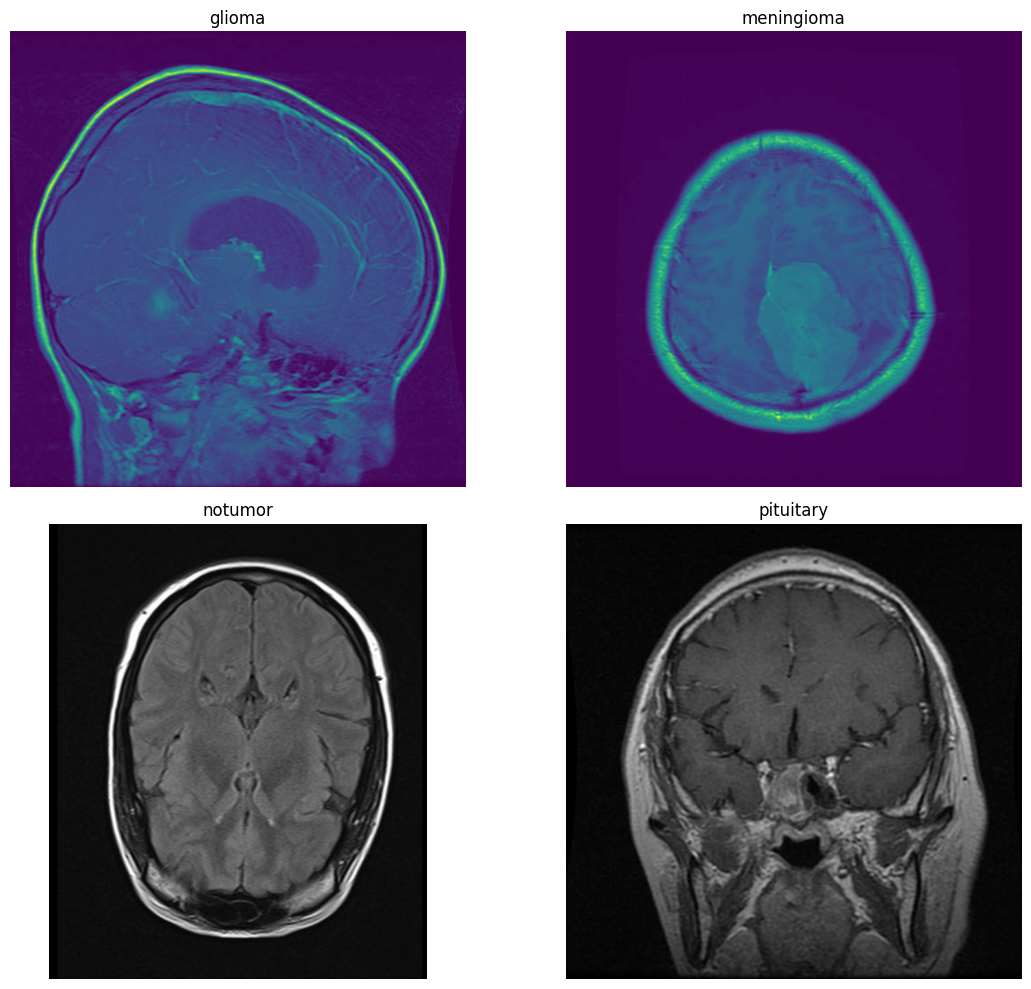

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = ["glioma", "meningioma", "notumor", "pituitary"]

plt.figure(figsize=(12, 10))

for i, class_name in enumerate(classes):
    class_dir = os.path.join(NICKPARVAR_DIR, "Training", class_name)

    image_files = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith(".jpg")
    ]

    random_file = random.choice(image_files)
    image_path = os.path.join(class_dir, random_file)

    image = Image.open(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import hashlib
from collections import defaultdict

image_hashes = defaultdict(list)

for split in ["Training", "Testing"]:
    split_dir = os.path.join(NICKPARVAR_DIR, split)

    for class_name in os.listdir(split_dir):
        class_dir = os.path.join(split_dir, class_name)

        if os.path.isdir(class_dir):
            for filename in os.listdir(class_dir):

                if filename.lower().endswith(".jpg"):
                    filepath = os.path.join(class_dir, filename)

                    with open(filepath, "rb") as f:
                        file_hash = hashlib.md5(f.read()).hexdigest()

                    image_hashes[file_hash].append(
                        (split, class_name, filename)
                    )

# Keep only hashes appearing more than once
duplicates = {
    h: files
    for h, files in image_hashes.items()
    if len(files) > 1
}

print("=" * 60)
print("EXACT DUPLICATE IMAGE CHECK")
print("=" * 60)

print(f"Unique image hashes : {len(image_hashes)}")
print(f"Duplicate groups    : {len(duplicates)}")

duplicate_files = sum(len(files) for files in duplicates.values())

print(f"Images involved     : {duplicate_files}")

if duplicates:
    print("\nDuplicate groups found:\n")

    for i, (file_hash, files) in enumerate(duplicates.items()):
        print(f"Group {i + 1}:")
        for file_info in files:
            print("  ", file_info)
        print()

else:
    print("\n✅ No exact duplicate images found.")

EXACT DUPLICATE IMAGE CHECK
Unique image hashes : 7013
Duplicate groups    : 171
Images involved     : 376

Duplicate groups found:

Group 1:
   ('Training', 'glioma', 'Tr-gl_632.jpg')
   ('Training', 'glioma', 'Tr-gl_632 (1).jpg')

Group 2:
   ('Training', 'meningioma', 'Tr-me_534.jpg')
   ('Training', 'meningioma', 'Tr-me_86.jpg')
   ('Training', 'meningioma', 'Tr-me_339.jpg')

Group 3:
   ('Training', 'meningioma', 'Tr-me_532.jpg')
   ('Training', 'meningioma', 'Tr-aug-me_97.jpg')

Group 4:
   ('Training', 'meningioma', 'Tr-me_1101.jpg')
   ('Training', 'meningioma', 'Tr-me_836.jpg')

Group 5:
   ('Training', 'meningioma', 'Tr-me_245.jpg')
   ('Training', 'meningioma', 'Tr-aug-me_91.jpg')

Group 6:
   ('Training', 'meningioma', 'Tr-me_268.jpg')
   ('Training', 'meningioma', 'Tr-aug-me_92.jpg')

Group 7:
   ('Training', 'meningioma', 'Tr-me_889.jpg')
   ('Training', 'meningioma', 'Tr-aug-me_89.jpg')

Group 8:
   ('Training', 'meningioma', 'Tr-me_1295.jpg')
   ('Training', 'meningioma

In [ ]:
print("=" * 60)
print("EXACT DUPLICATE SUMMARY")
print("=" * 60)

print(f"Total duplicate groups : {len(duplicates)}")
print(f"Total duplicate images : {sum(len(files) for files in duplicates.values())}")

cross_split = []

for file_hash, files in duplicates.items():
    splits = {item[0] for item in files}

    if len(splits) > 1:
        cross_split.append(files)

print(f"Cross-split duplicates  : {len(cross_split)}")

if cross_split:
    print("\n⚠️ Cross-split duplicates found:")
    for group in cross_split:
        for item in group:
            print("  ", item)
        print()
else:
    print("\n✅ No exact duplicates between Training and Testing.")

EXACT DUPLICATE SUMMARY
Total duplicate groups : 171
Total duplicate images : 376
Cross-split duplicates  : 0

✅ No exact duplicates between Training and Testing.


In [ ]:
import os

print("=" * 60)
print("DATASET FILE / FOLDER STRUCTURE")
print("=" * 60)

for root, dirs, files in os.walk(NICKPARVAR_DIR):
    level = root.replace(NICKPARVAR_DIR, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    # Show only first 5 files in each folder
    for file in sorted(files)[:5]:
        print(f"{indent}    {file}")

    if len(files) > 5:
        print(f"{indent}    ... ({len(files)} files total)")

DATASET FILE / FOLDER STRUCTURE
NickParvar/
    Testing/
        pituitary/
            Te-pi_1.jpg
            Te-pi_10.jpg
            Te-pi_100.jpg
            Te-pi_101.jpg
            Te-pi_102.jpg
            ... (416 files total)
        meningioma/
            Te-aug-me_1.jpg
            Te-aug-me_10.jpg
            Te-aug-me_100.jpg
            Te-aug-me_101.jpg
            Te-aug-me_102.jpg
            ... (400 files total)
        notumor/
            Te-no_1.jpg
            Te-no_10.jpg
            Te-no_100.jpg
            Te-no_101.jpg
            Te-no_102.jpg
            ... (400 files total)
        glioma/
            Te-gl_1.jpg
            Te-gl_10.jpg
            Te-gl_100.jpg
            Te-gl_101.jpg
            Te-gl_102.jpg
            ... (401 files total)
    Training/
        glioma/
            Tr-gl_1.jpg
            Tr-gl_10.jpg
            Tr-gl_100.jpg
            Tr-gl_1000.jpg
            Tr-gl_1001.jpg
            ... (1401 files total)
        menin

In [ ]:
import imagehash
print("ImageHash is available:", imagehash.__name__)

ImageHash is available: imagehash


In [ ]:
try:
    import imagehash
    print("✅ imagehash is installed")
    print("Version:", getattr(imagehash, "__version__", "unknown"))
except ImportError:
    print("❌ imagehash is NOT installed")

✅ imagehash is installed
Version: 4.3.2


In [ ]:
import os
import imagehash
from PIL import Image
from collections import defaultdict

phash_groups = defaultdict(list)

for split in ["Training", "Testing"]:
    split_dir = os.path.join(NICKPARVAR_DIR, split)

    for class_name in os.listdir(split_dir):
        class_dir = os.path.join(split_dir, class_name)

        if os.path.isdir(class_dir):
            for filename in os.listdir(class_dir):

                if filename.lower().endswith(".jpg"):
                    filepath = os.path.join(class_dir, filename)

                    try:
                        with Image.open(filepath) as img:
                            phash = str(imagehash.phash(img))

                        phash_groups[phash].append(
                            (split, class_name, filename)
                        )

                    except Exception as e:
                        print(f"Error: {filepath} -> {e}")

# Exact same perceptual hash
near_duplicate_groups = {
    h: files
    for h, files in phash_groups.items()
    if len(files) > 1
}

print("=" * 60)
print("PERCEPTUAL HASH CHECK")
print("=" * 60)

print(f"Unique perceptual hashes : {len(phash_groups)}")
print(f"Repeated hash groups    : {len(near_duplicate_groups)}")

total_in_groups = sum(
    len(files) for files in near_duplicate_groups.values()
)

print(f"Images in repeated groups: {total_in_groups}")

cross_split_groups = []

for files in near_duplicate_groups.values():
    splits = {item[0] for item in files}

    if len(splits) > 1:
        cross_split_groups.append(files)

print(f"Cross-split groups       : {len(cross_split_groups)}")

if cross_split_groups:
    print("\n⚠️ Potential Training ↔ Testing near-duplicates:")

    for i, group in enumerate(cross_split_groups[:20], 1):
        print(f"\nGroup {i}:")
        for item in group:
            print("   ", item)

    if len(cross_split_groups) > 20:
        print(f"\n... and {len(cross_split_groups) - 20} more groups.")

else:
    print("\n✅ No identical perceptual-hash groups between Training and Testing.")

PERCEPTUAL HASH CHECK
Unique perceptual hashes : 6212
Repeated hash groups    : 610
Images in repeated groups: 1616
Cross-split groups       : 294

⚠️ Potential Training ↔ Testing near-duplicates:

Group 1:
    ('Training', 'glioma', 'Tr-gl_361.jpg')
    ('Testing', 'glioma', 'Te-gl_364.jpg')
    ('Testing', 'glioma', 'Te-gl_299.jpg')

Group 2:
    ('Training', 'glioma', 'Tr-gl_1271.jpg')
    ('Testing', 'glioma', 'Te-gl_169.jpg')

Group 3:
    ('Training', 'glioma', 'Tr-gl_420.jpg')
    ('Testing', 'glioma', 'Te-gl_233.jpg')

Group 4:
    ('Training', 'glioma', 'Tr-gl_1057.jpg')
    ('Testing', 'glioma', 'Te-gl_311.jpg')

Group 5:
    ('Training', 'meningioma', 'Tr-me_145.jpg')
    ('Testing', 'meningioma', 'Te-me_296.jpg')

Group 6:
    ('Training', 'meningioma', 'Tr-me_464.jpg')
    ('Training', 'meningioma', 'Tr-me_639.jpg')
    ('Testing', 'meningioma', 'Te-me_262.jpg')
    ('Testing', 'meningioma', 'Te-me_214.jpg')

Group 7:
    ('Training', 'meningioma', 'Tr-me_771.jpg')
    ('T

In [ ]:
print("=" * 60)
print("NEAR-DUPLICATE SUMMARY")
print("=" * 60)

print(f"Total repeated pHash groups : {len(near_duplicate_groups)}")
print(f"Images in repeated groups   : {total_in_groups}")
print(f"Cross-split groups          : {len(cross_split_groups)}")

training_groups = 0
testing_groups = 0
cross_groups = 0

for files in near_duplicate_groups.values():
    splits = {item[0] for item in files}

    if "Training" in splits and "Testing" not in splits:
        training_groups += 1

    elif "Testing" in splits and "Training" not in splits:
        testing_groups += 1

    elif "Training" in splits and "Testing" in splits:
        cross_groups += 1

print("\nBreakdown:")
print(f"Training-only groups        : {training_groups}")
print(f"Testing-only groups         : {testing_groups}")
print(f"Training ↔ Testing groups  : {cross_groups}")

NEAR-DUPLICATE SUMMARY
Total repeated pHash groups : 610
Images in repeated groups   : 1616
Cross-split groups          : 294

Breakdown:
Training-only groups        : 258
Testing-only groups         : 58
Training ↔ Testing groups  : 294


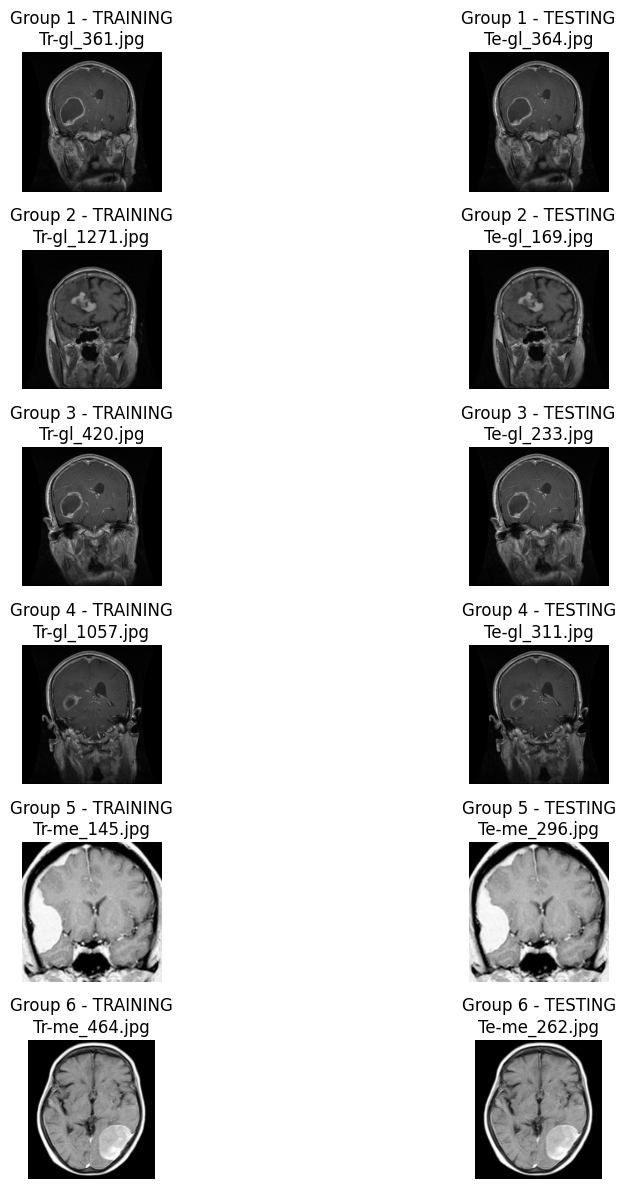

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select first 6 cross-split groups for visual inspection
sample_groups = cross_split_groups[:6]

plt.figure(figsize=(12, 12))

plot_index = 1

for group_number, group in enumerate(sample_groups, 1):

    training_items = [x for x in group if x[0] == "Training"]
    testing_items = [x for x in group if x[0] == "Testing"]

    # Take one image from each split
    train_item = training_items[0]
    test_item = testing_items[0]

    train_path = os.path.join(
        NICKPARVAR_DIR,
        train_item[0],
        train_item[1],
        train_item[2]
    )

    test_path = os.path.join(
        NICKPARVAR_DIR,
        test_item[0],
        test_item[1],
        test_item[2]
    )

    train_img = Image.open(train_path)
    test_img = Image.open(test_path)

    # Training image
    plt.subplot(6, 2, plot_index)
    plt.imshow(train_img)
    plt.title(f"Group {group_number} - TRAINING\n{train_item[2]}")
    plt.axis("off")

    plot_index += 1

    # Testing image
    plt.subplot(6, 2, plot_index)
    plt.imshow(test_img)
    plt.title(f"Group {group_number} - TESTING\n{test_item[2]}")
    plt.axis("off")

    plot_index += 1

plt.tight_layout()
plt.show()

In [ ]:
import os
from collections import Counter

print("=" * 60)
print("FILENAME PATTERN ANALYSIS")
print("=" * 60)

for split in ["Training", "Testing"]:

    print(f"\n{split}")
    print("-" * 40)

    split_dir = os.path.join(NICKPARVAR_DIR, split)

    for class_name in sorted(os.listdir(split_dir)):

        class_dir = os.path.join(split_dir, class_name)

        if not os.path.isdir(class_dir):
            continue

        files = [
            f for f in os.listdir(class_dir)
            if f.lower().endswith(".jpg")
        ]

        augmented = [
            f for f in files
            if "aug" in f.lower()
        ]

        regular = [
            f for f in files
            if "aug" not in f.lower()
        ]

        print(f"{class_name:15} : total={len(files):4} | "
              f"aug={len(augmented):4} | "
              f"regular={len(regular):4}")

FILENAME PATTERN ANALYSIS

Training
----------------------------------------
glioma          : total=1401 | aug=   0 | regular=1401
meningioma      : total=1400 | aug= 100 | regular=1300
notumor         : total=1400 | aug=   0 | regular=1400
pituitary       : total=1400 | aug=   0 | regular=1400

Testing
----------------------------------------
glioma          : total= 401 | aug=   0 | regular= 401
meningioma      : total= 400 | aug= 103 | regular= 297
notumor         : total= 400 | aug=   0 | regular= 400
pituitary       : total= 416 | aug=   0 | regular= 416


In [ ]:
import os
import pandas as pd

records = []

for split in ["Training", "Testing"]:
    split_dir = os.path.join(NICKPARVAR_DIR, split)

    for class_name in sorted(os.listdir(split_dir)):
        class_dir = os.path.join(split_dir, class_name)

        if os.path.isdir(class_dir):
            count = len([
                f for f in os.listdir(class_dir)
                if f.lower().endswith(".jpg")
            ])

            records.append({
                "Split": split,
                "Class": class_name,
                "Images": count
            })

distribution_df = pd.DataFrame(records)

print(distribution_df.to_string(index=False))

print("\n" + "=" * 60)
print("TOTAL BY CLASS")
print("=" * 60)

print(
    distribution_df
    .groupby("Class")["Images"]
    .sum()
    .sort_index()
    .to_string()
)

print("\n" + "=" * 60)
print("TOTAL DATASET")
print("=" * 60)

print(distribution_df["Images"].sum())

   Split      Class  Images
Training     glioma    1401
Training meningioma    1400
Training    notumor    1400
Training  pituitary    1400
 Testing     glioma     401
 Testing meningioma     400
 Testing    notumor     400
 Testing  pituitary     416

TOTAL BY CLASS
Class
glioma        1802
meningioma    1800
notumor       1800
pituitary     1816

TOTAL DATASET
7218


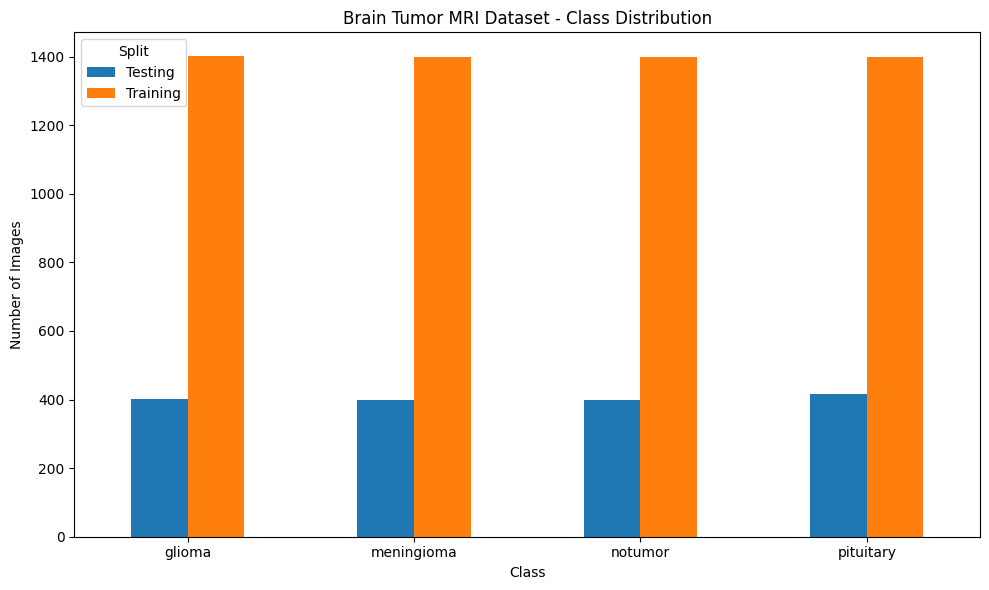

Chart saved to:
/content/drive/MyDrive/BrainTumorProject/results/class_distribution.png


In [ ]:
import matplotlib.pyplot as plt
import os

# Pivot data for plotting
plot_df = distribution_df.pivot(
    index="Class",
    columns="Split",
    values="Images"
)

# Create chart
ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Brain Tumor MRI Dataset - Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Split")
plt.tight_layout()

# Save to persistent Drive
chart_path = os.path.join(
    RESULTS_DIR,
    "class_distribution.png"
)

plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Chart saved to:")
print(chart_path)

In [ ]:
import os
from datetime import datetime

report_path = os.path.join(
    RESULTS_DIR,
    "phase_1_dataset_report.txt"
)

report = f"""
============================================================
BRAIN TUMOR MRI CLASSIFICATION
PHASE 1 — DATASET EXPLORATION REPORT
============================================================

Dataset:
NickParvar Brain Tumor MRI Dataset

Dataset location:
{NICKPARVAR_DIR}

Total images:
7,218

------------------------------------------------------------
1. CLASS DISTRIBUTION
------------------------------------------------------------

Training:
    Glioma       : 1,401
    Meningioma   : 1,400
    No Tumor     : 1,400
    Pituitary    : 1,400
    Total        : 5,601

Testing:
    Glioma       : 401
    Meningioma   : 400
    No Tumor     : 400
    Pituitary    : 416
    Total        : 1,617

Overall:
    Glioma       : 1,802
    Meningioma   : 1,800
    No Tumor     : 1,800
    Pituitary    : 1,816
    Total        : 7,218

Class imbalance:
    Dataset is approximately balanced.

------------------------------------------------------------
2. FILE FORMAT
------------------------------------------------------------

All 7,218 images are JPG files.

------------------------------------------------------------
3. IMAGE DIMENSIONS
------------------------------------------------------------

Images have highly variable dimensions.

Most common:
    512 x 512 : 5,032 images

Other dimensions are also present.

------------------------------------------------------------
4. IMAGE MODES / CHANNELS
------------------------------------------------------------

RGB  : 4,131
L    : 3,083
RGBA : 3
P    : 1

Images are therefore not uniformly RGB.

------------------------------------------------------------
5. CORRUPTED IMAGE CHECK
------------------------------------------------------------

Images checked : 7,218
Corrupted      : 0

Result:
No corrupted images detected.

------------------------------------------------------------
6. EXACT DUPLICATE CHECK
------------------------------------------------------------

Duplicate groups      : 171
Images in groups      : 376
Cross-split duplicates: 0

Result:
No exact Training ↔ Testing duplicates detected.

------------------------------------------------------------
7. NEAR-DUPLICATE / PERCEPTUAL HASH CHECK
------------------------------------------------------------

Repeated pHash groups : 610
Images in groups      : 1,616
Training-only groups  : 258
Testing-only groups   : 58
Cross-split groups    : 294

Result:
294 cross-split groups were identified as potential
near-duplicate groups using perceptual hashing.

Visual inspection confirmed strong visual similarity
in representative Training ↔ Testing examples.

Important limitation:
pHash similarity does not prove that images are the same
patient or the exact same MRI image.

------------------------------------------------------------
8. PATIENT METADATA
------------------------------------------------------------

No patient-level metadata or patient-ID structure was found
in the inspected dataset folders.

Therefore, patient-level splitting cannot currently be
guaranteed using the available dataset structure.

------------------------------------------------------------
9. FILENAME / AUGMENTATION PATTERN
------------------------------------------------------------

Training meningioma:
    100 filenames contain "aug"

Testing meningioma:
    103 filenames contain "aug"

Total explicitly "aug"-named images:
    203

This is recorded as a dataset-quality consideration.
Filename patterns alone do not prove leakage.

------------------------------------------------------------
10. DATASET QUALITY CONCLUSION
------------------------------------------------------------

Strengths:
    - 7,218 usable JPG images
    - Four clearly defined classes
    - Approximately balanced classes
    - No corrupted images detected
    - No exact Training ↔ Testing duplicates detected

Concerns:
    - Highly variable image dimensions
    - Mixed image modes/channels
    - 294 potential cross-split near-duplicate groups
    - No patient-level metadata available
    - Explicitly augmented filenames exist in meningioma data

The existing Training/Testing split should not automatically
be treated as a leakage-free patient-independent evaluation.

These findings must be considered when constructing the
leakage-aware preprocessing and splitting strategy in Phase 2.

------------------------------------------------------------
Generated:
{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
============================================================
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print("✅ Phase 1 dataset report saved successfully.")
print()
print(report_path)

✅ Phase 1 dataset report saved successfully.

/content/drive/MyDrive/BrainTumorProject/results/phase_1_dataset_report.txt


PHASE 1 ENDS

PHASE 2 STARTS

In [ ]:
import os
import pandas as pd
from pathlib import Path

# Dataset path
DATASET_DIR = Path("/content/drive/MyDrive/BrainTumorProject/dataset/NickParvar")

# Class mapping
CLASS_NAMES = {
    "notumor": 0,
    "glioma": 1,
    "meningioma": 2,
    "pituitary": 3
}

print("Dataset directory:", DATASET_DIR)
print("Exists:", DATASET_DIR.exists())

Dataset directory: /content/drive/MyDrive/BrainTumorProject/dataset/NickParvar
Exists: True


In [ ]:
# Phase 2 Cell 1: Phase 2 Initialization - Load shared infrastructure and required artifacts
import os
import pandas as pd
from pathlib import Path

# ============================================================
# PHASE 2 — LEAKAGE-AWARE DATA SPLITTING
# ============================================================

print("=" * 60)
print("PHASE 2 — LEAKAGE-AWARE DATA SPLITTING INITIALIZATION")
print("=" * 60)

# Initialize shared infrastructure (can be called independently)
def setup_drive_and_paths():
    """Robust Google Drive setup and centralized path configuration."""
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive'):
            drive.mount('/content/drive')
            print("Google Drive mounted successfully.")
        else:
            print("Google Drive already mounted.")
    except ImportError:
        print("Not running in Google Colab - Drive mounting skipped.")
    
    PROJECT_ROOT = Path("/content/drive/MyDrive/BrainTumorProject")
    
    if not PROJECT_ROOT.exists():
        raise FileNotFoundError(
            f"Project root not found: {PROJECT_ROOT}\n"
            "Please ensure the BrainTumorProject directory exists in Google Drive."
        )
    
    paths = {
        'PROJECT_ROOT': PROJECT_ROOT,
        'DATASET_DIR': PROJECT_ROOT / "dataset",
        'MODEL_DIR': PROJECT_ROOT / "models",
        'RESULTS_DIR': PROJECT_ROOT / "results",
        'LOGS_DIR': PROJECT_ROOT / "logs",
    }
    
    for path_name in ['MODEL_DIR', 'RESULTS_DIR', 'LOGS_DIR']:
        paths[path_name].mkdir(parents=True, exist_ok=True)
    
    return paths

def get_class_configuration():
    """Returns standardized class configuration used across all phases."""
    CLASS_NAMES = [
        "No Tumor",
        "Glioma", 
        "Meningioma",
        "Pituitary Tumor"
    ]
    
    CLASS_MAPPING = {
        "notumor": 0,
        "glioma": 1,
        "meningioma": 2,
        "pituitary": 3
    }
    
    NUM_CLASSES = len(CLASS_NAMES)
    
    return {
        'CLASS_NAMES': CLASS_NAMES,
        'CLASS_MAPPING': CLASS_MAPPING,
        'NUM_CLASSES': NUM_CLASSES
    }

def get_device():
    """Get the appropriate device for computation."""
    import torch
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize paths
PATHS = setup_drive_and_paths()

# Initialize class configuration
CLASS_CONFIG = get_class_configuration()
CLASS_NAMES = CLASS_CONFIG['CLASS_NAMES']
CLASS_MAPPING = CLASS_CONFIG['CLASS_MAPPING']
NUM_CLASSES = CLASS_CONFIG['NUM_CLASSES']

# Initialize device
DEVICE = get_device()

# Define Phase 2 specific paths
DATASET_DIR = PATHS['DATASET_DIR']
RESULTS_DIR = PATHS['RESULTS_DIR']
MODEL_DIR = PATHS['MODEL_DIR']
NICKPARVAR_DIR = DATASET_DIR / "NickParvar"

# Verify dataset directory exists
if not NICKPARVAR_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory not found: {NICKPARVAR_DIR}\n"
        "Please ensure the NickParvar dataset exists in the dataset folder."
    )

print(f"Dataset path: {NICKPARVAR_DIR}")
print(f"Device: {DEVICE}")
print(f"Classes: {NUM_CLASSES}")
print("=" * 60)

In [ ]:
# Phase 2 Cell 2: Build complete image index from dataset
from pathlib import Path

# Dataset path
DATASET_DIR_PATH = Path(NICKPARVAR_DIR)

# Class mapping
CLASS_NAMES_MAPPING = CLASS_MAPPING

print("Dataset directory:", DATASET_DIR_PATH)
print("Exists:", DATASET_DIR_PATH.exists())

# Build complete image index
records = []

for split in ["Training", "Testing"]:
    split_dir = DATASET_DIR_PATH / split

    for class_name, class_id in CLASS_NAMES_MAPPING.items():
        class_dir = split_dir / class_name

        if class_dir.exists():
            for image_path in class_dir.glob("*.jpg"):
                records.append({
                    "filepath": str(image_path),
                    "class_name": class_name,
                    "class_id": class_id,
                    "original_split": split
                })

df = pd.DataFrame(records)

print("Total images:", len(df))
print("\nFirst 5 rows:")
print(df.head())

In [ ]:
# Save the complete image index to Google Drive

INDEX_PATH = Path(
    "/content/drive/MyDrive/BrainTumorProject/results/image_index.csv"
)

df.to_csv(INDEX_PATH, index=False)

print("Image index saved successfully.")
print("Path:", INDEX_PATH)
print("Rows saved:", len(df))

Image index saved successfully.
Path: /content/drive/MyDrive/BrainTumorProject/results/image_index.csv
Rows saved: 7218


In [ ]:
import os

print("Files in results folder:")
for file in os.listdir(RESULTS_DIR):
    print(file)

Files in results folder:
gradcam
class_distribution.png
phase_1_dataset_report.txt
image_index.csv
phash_groups.csv
train_split.csv
validation_split.csv
test_split.csv
cnn_baseline_metrics.json
cnn_baseline_loss.png
cnn_baseline_accuracy.png
cnn_baseline_confusion_matrix.png
cnn_baseline_classification_report.txt
phase_3_cnn_baseline_summary.txt


In [ ]:
!pip -q install ImageHash


In [ ]:
import imagehash
print("ImageHash is available for perceptual hashing.")

ImageHash is available for perceptual hashing.


In [ ]:
from pathlib import Path
import pandas as pd
import imagehash
from PIL import Image
from tqdm.auto import tqdm

phash_records = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Computing pHash"):
    image_path = row["filepath"]

    try:
        with Image.open(image_path) as image:
            phash = str(imagehash.phash(image.convert("RGB")))

        phash_records.append({
            "filepath": image_path,
            "class_name": row["class_name"],
            "class_id": row["class_id"],
            "original_split": row["original_split"],
            "phash": phash
        })

    except Exception as error:
        print(f"Skipped {image_path}: {error}")

phash_df = pd.DataFrame(phash_records)

PHASH_PATH = Path(
    "/content/drive/MyDrive/BrainTumorProject/results/phash_groups.csv"
)
PHASH_PATH.parent.mkdir(parents=True, exist_ok=True)

phash_df.to_csv(PHASH_PATH, index=False)

print("pHash results saved successfully.")
print("Path:", PHASH_PATH)
print("Rows saved:", len(phash_df))
print("Unique pHashes:", phash_df["phash"].nunique())

Computing pHash:   0%|          | 0/7218 [00:00<?, ?it/s]

pHash results saved successfully.
Path: /content/drive/MyDrive/BrainTumorProject/results/phash_groups.csv
Rows saved: 7218
Unique pHashes: 6212


In [ ]:
PHASH_PATH = Path(
    "/content/drive/MyDrive/BrainTumorProject/results/phash_groups.csv"
)

phash_df.to_csv(PHASH_PATH, index=False)

print("pHash results saved successfully.")
print("Path:", PHASH_PATH)
print("Rows saved:", len(phash_df))

pHash results saved successfully.
Path: /content/drive/MyDrive/BrainTumorProject/results/phash_groups.csv
Rows saved: 7218


In [ ]:
# Find pHashes that occur more than once

phash_counts = phash_df["phash"].value_counts()

duplicate_phashes = phash_counts[phash_counts > 1]

print("Repeated pHash values:", len(duplicate_phashes))
print("Images belonging to repeated pHashes:", duplicate_phashes.sum())

print("\nTop repeated pHashes:")
display(duplicate_phashes.head(20))

Repeated pHash values: 610
Images belonging to repeated pHashes: 1616

Top repeated pHashes:


,count
phash,
907a6fc56d92344d,18
856a5ba57ab50996,13
d0c00f0f2f1f7c3c,11
91971ed87a24795c,10
96386a716dc534e3,10
c3433eb87a87701b,8
876a7e31789568c6,8
d03f0ef02fe03cc3,8
9ec969b467329661,7


In [ ]:
# Analyze whether repeated pHash groups contain
# images from both Training and Testing.

group_analysis = (
    phash_df[phash_df["phash"].isin(duplicate_phashes.index)]
    .groupby("phash")
    .agg(
        image_count=("filepath", "count"),
        split_count=("original_split", "nunique"),
        splits=("original_split", lambda x: ", ".join(sorted(x.unique()))),
        classes=("class_name", lambda x: ", ".join(sorted(x.unique())))
    )
    .reset_index()
)

cross_split_groups = group_analysis[
    group_analysis["split_count"] > 1
]

print("Total repeated pHash groups:", len(group_analysis))
print("Cross-split pHash groups:", len(cross_split_groups))
print(
    "Images belonging to cross-split groups:",
    cross_split_groups["image_count"].sum()
)

print("\nCross-split group examples:")
display(cross_split_groups.head(20))

Total repeated pHash groups: 610
Cross-split pHash groups: 294
Images belonging to cross-split groups: 855

Cross-split group examples:


,phash,image_count,split_count,splits,classes
1,801f5ffa29687d21,2,2,"Testing, Training",meningioma
2,80375f693ab07c65,2,2,"Testing, Training",meningioma
8,80625f4b3a27799d,2,2,"Testing, Training",notumor
14,811e1fe87aa53ac5,2,2,"Testing, Training",meningioma
17,811e63e81eb50bf9,2,2,"Testing, Training",meningioma
18,811e63e81eb50fe9,2,2,"Testing, Training",meningioma
19,811f5e722e6b6c19,2,2,"Testing, Training",meningioma
20,815a5f28669d6997,2,2,"Testing, Training",meningioma
21,815a5f28669d6a97,2,2,"Testing, Training",meningioma
24,815e5f2a70e957a1,2,2,"Testing, Training",meningioma


In [ ]:
# Assign a group ID to every identical-pHash group.
# Images with the same pHash will belong to the same group.

phash_df["group_id"] = phash_df["phash"].factorize()[0]

print("Total images:", len(phash_df))
print("Total groups:", phash_df["group_id"].nunique())

# Check group sizes
group_sizes = phash_df["group_id"].value_counts()

print("\nLargest groups:")
display(group_sizes.head(20))

Total images: 7218
Total groups: 6212

Largest groups:


,count
group_id,
107,18
216,13
2,11
28,10
199,10
39,8
11,8
185,8
180,7


In [ ]:
# Analyze group sizes

group_size_counts = (
    phash_df.groupby("group_id")
    .size()
    .value_counts()
    .sort_index()
)

print("Number of groups:", phash_df["group_id"].nunique())
print("\nGroup size distribution:")
display(group_size_counts)

print("\nMaximum group size:", phash_df.groupby("group_id").size().max())

Number of groups: 6212

Group size distribution:


,count
1,5602
2,424
3,89
4,51
5,23
6,9
7,6
8,3
10,2
11,1



Maximum group size: 18


In [ ]:
# Verify that each group_id corresponds to exactly one pHash

group_phash_check = (
    phash_df.groupby("group_id")["phash"]
    .nunique()
)

print("Groups with multiple pHashes:", (group_phash_check > 1).sum())
print("Groups with exactly one pHash:", (group_phash_check == 1).sum())

assert (group_phash_check == 1).all()

print("\nGroup integrity check: PASSED")

Groups with multiple pHashes: 0
Groups with exactly one pHash: 6212

Group integrity check: PASSED


In [ ]:
# Check whether any pHash group contains images from multiple classes

group_class_check = (
    phash_df.groupby("group_id")["class_name"]
    .nunique()
)

multi_class_groups = group_class_check[group_class_check > 1]

print("Total groups:", len(group_class_check))
print("Groups containing multiple classes:", len(multi_class_groups))

if len(multi_class_groups) > 0:
    print("\nExamples:")
    display(
        phash_df[
            phash_df["group_id"].isin(multi_class_groups.index)
        ].sort_values("group_id").head(30)
    )
else:
    print("All groups contain images from only one class.")

Total groups: 6212
Groups containing multiple classes: 1

Examples:


,filepath,class_name,class_id,original_split,phash,group_id
2949,/content/drive/MyDrive/BrainTumorProject/datas...,meningioma,2,Training,901a7f616de436a6,2456
6365,/content/drive/MyDrive/BrainTumorProject/datas...,glioma,1,Testing,901a7f616de436a6,2456
6673,/content/drive/MyDrive/BrainTumorProject/datas...,meningioma,2,Testing,901a7f616de436a6,2456


In [ ]:
# Identify ambiguous groups containing more than one class

ambiguous_groups = (
    phash_df.groupby("group_id")["class_id"]
    .nunique()
)

ambiguous_groups = ambiguous_groups[
    ambiguous_groups > 1
].index.tolist()

print("Ambiguous group IDs:", ambiguous_groups)

# Separate them
ambiguous_df = phash_df[
    phash_df["group_id"].isin(ambiguous_groups)
].copy()

print("\nImages in ambiguous groups:", len(ambiguous_df))

display(
    ambiguous_df[
        ["filepath", "class_name", "class_id",
         "original_split", "phash", "group_id"]
    ]
)

Ambiguous group IDs: [2456]

Images in ambiguous groups: 3


,filepath,class_name,class_id,original_split,phash,group_id
2949,/content/drive/MyDrive/BrainTumorProject/datas...,meningioma,2,Training,901a7f616de436a6,2456
6365,/content/drive/MyDrive/BrainTumorProject/datas...,glioma,1,Testing,901a7f616de436a6,2456
6673,/content/drive/MyDrive/BrainTumorProject/datas...,meningioma,2,Testing,901a7f616de436a6,2456


In [ ]:
# Remove ambiguous pHash groups from the automatic splitting pool

split_df = phash_df[
    ~phash_df["group_id"].isin(ambiguous_groups)
].copy()

print("Original images:", len(phash_df))
print("Ambiguous images excluded:", len(ambiguous_df))
print("Images available for splitting:", len(split_df))

print("\nClass distribution after exclusion:")
print(split_df["class_name"].value_counts().sort_index())

Original images: 7218
Ambiguous images excluded: 3
Images available for splitting: 7215

Class distribution after exclusion:
class_name
glioma        1801
meningioma    1798
notumor       1800
pituitary     1816
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

print("StratifiedGroupKFold imported successfully.")

StratifiedGroupKFold imported successfully.


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

RANDOM_STATE = 42

# ---------------------------------------------------------
# First split:
# ~70% Training
# ~30% Temporary Holdout
# ---------------------------------------------------------

sgkf = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

# We need one fold for the holdout.
# 1 fold ≈ 10%, so combine 3 folds for ≈ 30%.
fold_assignments = {}

for fold, (_, holdout_idx) in enumerate(
    sgkf.split(
        split_df,
        y=split_df["class_id"],
        groups=split_df["group_id"]
    )
):
    for idx in holdout_idx:
        fold_assignments[idx] = fold

split_df["_fold"] = split_df.index.map(fold_assignments)

# Use folds 0, 1, 2 as temporary holdout
holdout_mask = split_df["_fold"].isin([0, 1, 2])

train_df = split_df[~holdout_mask].copy()
holdout_df = split_df[holdout_mask].copy()

print("Training images:", len(train_df))
print("Temporary holdout images:", len(holdout_df))

print("\nTraining class distribution:")
print(train_df["class_name"].value_counts().sort_index())

print("\nHoldout class distribution:")
print(holdout_df["class_name"].value_counts().sort_index())

Training images: 5043
Temporary holdout images: 2172

Training class distribution:
class_name
glioma        1261
meningioma    1258
notumor       1255
pituitary     1269
Name: count, dtype: int64

Holdout class distribution:
class_name
glioma        540
meningioma    540
notumor       545
pituitary     547
Name: count, dtype: int64


In [ ]:
# ---------------------------------------------------------
# Second split:
# Temporary Holdout → Validation + Test
# ---------------------------------------------------------

sgkf_holdout = StratifiedGroupKFold(
    n_splits=2,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Generate the two folds
val_indices, test_indices = next(
    sgkf_holdout.split(
        holdout_df,
        y=holdout_df["class_id"],
        groups=holdout_df["group_id"]
    )
)

val_df = holdout_df.iloc[val_indices].copy()
test_df = holdout_df.iloc[test_indices].copy()

# Remove temporary helper column
for dataset in [train_df, val_df, test_df]:
    if "_fold" in dataset.columns:
        dataset.drop(columns=["_fold"], inplace=True)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

print("\nPercentages:")
total = len(train_df) + len(val_df) + len(test_df)

print(f"Training:   {len(train_df)/total*100:.2f}%")
print(f"Validation: {len(val_df)/total*100:.2f}%")
print(f"Testing:    {len(test_df)/total*100:.2f}%")

print("\nClass distribution:")
print(
    pd.DataFrame({
        "Train": train_df["class_name"].value_counts(),
        "Validation": val_df["class_name"].value_counts(),
        "Test": test_df["class_name"].value_counts()
    }).sort_index()
)

Training images: 5043
Validation images: 1112
Testing images: 1060

Percentages:
Training:   69.90%
Validation: 15.41%
Testing:    14.69%

Class distribution:
            Train  Validation  Test
class_name                         
glioma       1261         270   270
meningioma   1258         264   276
notumor      1255         303   242
pituitary    1269         275   272


In [ ]:
# Inspect the initial split attempt without stopping the notebook.
# This intentionally failed approach is discarded in the next cell.

train_groups = set(train_df["group_id"])
val_groups = set(val_df["group_id"])
test_groups = set(test_df["group_id"])

train_val_overlap = train_groups & val_groups
train_test_overlap = train_groups & test_groups
val_test_overlap = val_groups & test_groups

overlap_counts = {
    "train_validation": len(train_val_overlap),
    "train_test": len(train_test_overlap),
    "validation_test": len(val_test_overlap)
}

print("Initial split overlap counts:", overlap_counts)
print("Initial split discarded; the final group-level split is built next.")

Initial split overlap counts: {'train_validation': 112, 'train_test': 68, 'validation_test': 0}
Initial split discarded; the final group-level split is built next.


In [ ]:
# Discard the invalid split
# We will rebuild it correctly from the original clean pool.

del train_df
del val_df
del test_df
del holdout_df

print("Invalid split discarded.")
print("Ready to rebuild the split from scratch.")

Invalid split discarded.
Ready to rebuild the split from scratch.


In [ ]:
import numpy as np

# ---------------------------------------------------------
# Create one row per clean pHash group
# ---------------------------------------------------------

group_df = (
    split_df
    .groupby("group_id")
    .agg(
        class_id=("class_id", "first"),
        class_name=("class_name", "first"),
        image_count=("filepath", "count")
    )
    .reset_index()
)

print("Total clean images:", len(split_df))
print("Total clean groups:", len(group_df))

print("\nGroups by class:")
display(
    group_df["class_name"]
    .value_counts()
    .sort_index()
)

print("\nImages represented by groups:")
display(
    group_df.groupby("class_name")["image_count"]
    .sum()
    .sort_index()
)

Total clean images: 7215
Total clean groups: 6211

Groups by class:


,count
class_name,
glioma,1774
meningioma,1666
notumor,1023
pituitary,1748



Images represented by groups:


,image_count
class_name,
glioma,1801
meningioma,1798
notumor,1800
pituitary,1816


In [ ]:
# ---------------------------------------------------------
# Global group-aware 70 / 15 / 15 split
# ---------------------------------------------------------

RANDOM_STATE = 42
rng = np.random.RandomState(RANDOM_STATE)

group_assignments = []

for class_id in sorted(group_df["class_id"].unique()):

    class_groups = group_df[
        group_df["class_id"] == class_id
    ].copy()

    # Shuffle groups reproducibly
    class_groups = class_groups.sample(
        frac=1,
        random_state=RANDOM_STATE + int(class_id)
    ).reset_index(drop=True)

    n_groups = len(class_groups)

    # Determine number of groups for each split
    n_train = int(round(n_groups * 0.70))
    n_val = int(round(n_groups * 0.15))

    # Remaining groups go to test
    n_test = n_groups - n_train - n_val

    class_groups.loc[:n_train - 1, "split"] = "train"

    class_groups.loc[
        n_train:n_train + n_val - 1,
        "split"
    ] = "validation"

    class_groups.loc[
        n_train + n_val:,
        "split"
    ] = "test"

    group_assignments.append(class_groups)

group_assignment_df = pd.concat(
    group_assignments,
    ignore_index=True
)

print("Total groups assigned:", len(group_assignment_df))

print("\nGroups by split:")
print(
    group_assignment_df["split"]
    .value_counts()
)

print("\nGroups by class and split:")
display(
    pd.crosstab(
        group_assignment_df["class_name"],
        group_assignment_df["split"]
    )
)

Total groups assigned: 6211

Groups by split:
split
train         4348
test           932
validation     931
Name: count, dtype: int64

Groups by class and split:


split,test,train,validation
class_name,,,
glioma,266,1242,266
meningioma,250,1166,250
notumor,154,716,153
pituitary,262,1224,262


In [ ]:
# ---------------------------------------------------------
# Map group-level assignments back to individual images
# ---------------------------------------------------------

group_split_map = group_assignment_df[["group_id", "split"]].copy()

final_df = split_df.merge(
    group_split_map,
    on="group_id",
    how="left",
    validate="many_to_one"
)

missing_split_count = int(final_df["split"].isna().sum())
print("Total images:", len(final_df))
print("Images without split:", missing_split_count)

assert len(final_df) == len(split_df)
assert missing_split_count == 0
assert set(final_df["split"].unique()) == {"train", "validation", "test"}

print("\nImages by split:")
print(final_df["split"].value_counts())

print("\nPercentages:")
print((final_df["split"].value_counts(normalize=True) * 100).round(2))

print("\nClass distribution:")
display(pd.crosstab(final_df["class_name"], final_df["split"]))

Total images: 7215
Images without split: 0

Images by split:
split
train         5054
test          1101
validation    1060
Name: count, dtype: int64

Percentages:
split
train         70.05
test          15.26
validation    14.69
Name: proportion, dtype: float64

Class distribution:


split,test,train,validation
class_name,,,
glioma,272,1259,270
meningioma,271,1263,264
notumor,280,1264,256
pituitary,278,1268,270


In [ ]:
# ---------------------------------------------------------
# FINAL GROUP INTEGRITY CHECK
# ---------------------------------------------------------

train_groups = set(
    final_df.loc[final_df["split"] == "train", "group_id"]
)

val_groups = set(
    final_df.loc[final_df["split"] == "validation", "group_id"]
)

test_groups = set(
    final_df.loc[final_df["split"] == "test", "group_id"]
)

train_val_overlap = train_groups & val_groups
train_test_overlap = train_groups & test_groups
val_test_overlap = val_groups & test_groups

print("Train ↔ Validation overlapping groups:", len(train_val_overlap))
print("Train ↔ Test overlapping groups:", len(train_test_overlap))
print("Validation ↔ Test overlapping groups:", len(val_test_overlap))

assert len(train_val_overlap) == 0
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

# Also verify every group appears exactly once
all_assigned_groups = train_groups | val_groups | test_groups

print("\nUnique groups assigned:", len(all_assigned_groups))
print("Expected groups:", len(group_df))

assert len(all_assigned_groups) == len(group_df)

print("\n======================================")
print("GROUP INTEGRITY CHECK: PASSED")
print("======================================")

Train ↔ Validation overlapping groups: 0
Train ↔ Test overlapping groups: 0
Validation ↔ Test overlapping groups: 0

Unique groups assigned: 6211
Expected groups: 6211

GROUP INTEGRITY CHECK: PASSED


In [ ]:
# ---------------------------------------------------------
# Save final leakage-aware splits to Google Drive
# ---------------------------------------------------------

from pathlib import Path

RESULTS_PATH = Path(RESULTS_DIR)

TRAIN_SPLIT_PATH = RESULTS_PATH / "train_split.csv"
VAL_SPLIT_PATH = RESULTS_PATH / "validation_split.csv"
TEST_SPLIT_PATH = RESULTS_PATH / "test_split.csv"

final_df[final_df["split"] == "train"].to_csv(
    TRAIN_SPLIT_PATH,
    index=False
)

final_df[final_df["split"] == "validation"].to_csv(
    VAL_SPLIT_PATH,
    index=False
)

final_df[final_df["split"] == "test"].to_csv(
    TEST_SPLIT_PATH,
    index=False
)

print("Final splits saved successfully.\n")

print("Train      :", TRAIN_SPLIT_PATH)
print("Validation :", VAL_SPLIT_PATH)
print("Test       :", TEST_SPLIT_PATH)

print("\nRows saved:")
print("Train      :", len(pd.read_csv(TRAIN_SPLIT_PATH)))
print("Validation :", len(pd.read_csv(VAL_SPLIT_PATH)))
print("Test       :", len(pd.read_csv(TEST_SPLIT_PATH)))

Final splits saved successfully.

Train      : /content/drive/MyDrive/BrainTumorProject/results/train_split.csv
Validation : /content/drive/MyDrive/BrainTumorProject/results/validation_split.csv
Test       : /content/drive/MyDrive/BrainTumorProject/results/test_split.csv

Rows saved:
Train      : 5054
Validation : 1060
Test       : 1101


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import torch


class BrainTumorDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path = row["filepath"]
        label = int(row["class_id"])

        with Image.open(image_path) as image:
            image = image.convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


print("BrainTumorDataset class created successfully.")

BrainTumorDataset class created successfully.


In [ ]:
# ---------------------------------------------------------
# Reload final splits from Google Drive
# ---------------------------------------------------------

from pathlib import Path
import pandas as pd

RESULTS_PATH = Path(RESULTS_DIR)

TRAIN_SPLIT_PATH = RESULTS_PATH / "train_split.csv"
VAL_SPLIT_PATH = RESULTS_PATH / "validation_split.csv"
TEST_SPLIT_PATH = RESULTS_PATH / "test_split.csv"

train_df = pd.read_csv(TRAIN_SPLIT_PATH)
val_df = pd.read_csv(VAL_SPLIT_PATH)
test_df = pd.read_csv(TEST_SPLIT_PATH)

print("Splits loaded successfully.\n")

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

Splits loaded successfully.

Train      : 5054
Validation : 1060
Test       : 1101


In [ ]:
# ---------------------------------------------------------
# Create PyTorch Dataset objects
# ---------------------------------------------------------

train_dataset = BrainTumorDataset(
    train_df,
    transform=train_transform
)

val_dataset = BrainTumorDataset(
    val_df,
    transform=eval_transform
)

test_dataset = BrainTumorDataset(
    test_df,
    transform=eval_transform
)

print("Datasets created successfully.\n")

print("Train dataset      :", len(train_dataset))
print("Validation dataset :", len(val_dataset))
print("Test dataset       :", len(test_dataset))

Datasets created successfully.

Train dataset      : 5054
Validation dataset : 1060
Test dataset       : 1101


In [ ]:
# ---------------------------------------------------------
# Test one sample from the training dataset
# ---------------------------------------------------------

sample_image, sample_label = train_dataset[0]

print("Image shape :", sample_image.shape)
print("Label       :", sample_label)
print("Image dtype :", sample_image.dtype)
print("Image min   :", sample_image.min().item())
print("Image max   :", sample_image.max().item())

Image shape : torch.Size([3, 224, 224])
Label       : 0
Image dtype : torch.float32
Image min   : -2.1179039478302
Image max   : 2.5877127647399902


In [ ]:
# ---------------------------------------------------------
# Create PyTorch DataLoaders
# ---------------------------------------------------------

from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = 0
PIN_MEMORY = DEVICE.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("DataLoaders created successfully.")
print("Train batches      :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches       :", len(test_loader))
print("Workers            :", NUM_WORKERS)
print("Pin memory         :", PIN_MEMORY)

DataLoaders created successfully.
Train batches      : 158
Validation batches : 34
Test batches       : 35
Workers            : 0
Pin memory         : True


In [ ]:
# ---------------------------------------------------------
# Test one training batch
# ---------------------------------------------------------

images, labels = next(iter(train_loader))

print("Images shape :", images.shape)
print("Labels shape :", labels.shape)
print("Image dtype  :", images.dtype)
print("Label dtype  :", labels.dtype)

print("\nUnique labels in batch:", labels.unique().tolist())

Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Image dtype  : torch.float32
Label dtype  : torch.int64

Unique labels in batch: [0, 1, 2, 3]


In [ ]:
# ---------------------------------------------------------
# Final Phase 2 Verification
# ---------------------------------------------------------

CLASS_NAMES = {
    0: "No Tumor",
    1: "Glioma",
    2: "Meningioma",
    3: "Pituitary Tumor"
}

print("=" * 60)
print("CLASS MAPPING")
print("=" * 60)

for class_id, class_name in CLASS_NAMES.items():
    print(f"{class_id} → {class_name}")

print("\n" + "=" * 60)
print("FINAL SPLIT DISTRIBUTION")
print("=" * 60)

for split_name, df in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Testing", test_df)
]:
    print(f"\n{split_name}: {len(df)} images")

    counts = df["class_id"].value_counts().sort_index()

    for class_id, count in counts.items():
        print(f"  {class_id} - {CLASS_NAMES[class_id]:<18}: {count}")

print("\n" + "=" * 60)
print("SPLIT TOTALS")
print("=" * 60)

print("Training   :", len(train_df))
print("Validation :", len(val_df))
print("Testing    :", len(test_df))
print("Total      :", len(train_df) + len(val_df) + len(test_df))

print("\n" + "=" * 60)
print("PHASE 2 VERIFICATION")
print("=" * 60)

print("✓ Dataset objects created")
print("✓ Images converted to RGB")
print("✓ Images resized to 224 × 224")
print("✓ Training augmentation enabled")
print("✓ Validation/Test deterministic")
print("✓ ImageNet normalization applied")
print("✓ DataLoaders working")
print("✓ Group-based split completed")
print("✓ No group overlap between splits")
print("✓ Ambiguous multi-class pHash group excluded")

print("\nPhase 2 preprocessing pipeline verified successfully.")

CLASS MAPPING
0 → No Tumor
1 → Glioma
2 → Meningioma
3 → Pituitary Tumor

FINAL SPLIT DISTRIBUTION

Training: 5054 images
  0 - No Tumor          : 1264
  1 - Glioma            : 1259
  2 - Meningioma        : 1263
  3 - Pituitary Tumor   : 1268

Validation: 1060 images
  0 - No Tumor          : 256
  1 - Glioma            : 270
  2 - Meningioma        : 264
  3 - Pituitary Tumor   : 270

Testing: 1101 images
  0 - No Tumor          : 280
  1 - Glioma            : 272
  2 - Meningioma        : 271
  3 - Pituitary Tumor   : 278

SPLIT TOTALS
Training   : 5054
Validation : 1060
Testing    : 1101
Total      : 7215

PHASE 2 VERIFICATION
✓ Dataset objects created
✓ Images converted to RGB
✓ Images resized to 224 × 224
✓ Training augmentation enabled
✓ Validation/Test deterministic
✓ ImageNet normalization applied
✓ DataLoaders working
✓ Group-based split completed
✓ No group overlap between splits
✓ Ambiguous multi-class pHash group excluded

Phase 2 preprocessing pipeline verified successf

PHASE 2 ENDS

PHASE 3 STARTS

In [ ]:
import torch
import torch.nn as nn


class SmallCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            # 224 -> 112 -> 56 -> 28
            # Final feature map: 128 × 28 × 28
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = SmallCNN(num_classes=NUM_CLASSES).to(DEVICE)

print(model)

SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [ ]:
# Phase 3 Cell 1: Phase 3 Initialization - Load shared infrastructure and Phase 2 artifacts
import os
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn

# ============================================================
# PHASE 3 — SMALL CNN BASELINE
# ============================================================

print("=" * 60)
print("PHASE 3 — SMALL CNN BASELINE INITIALIZATION")
print("=" * 60)

# Initialize shared infrastructure (can be called independently)
def setup_drive_and_paths():
    """Robust Google Drive setup and centralized path configuration."""
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive'):
            drive.mount('/content/drive')
            print("Google Drive mounted successfully.")
        else:
            print("Google Drive already mounted.")
    except ImportError:
        print("Not running in Google Colab - Drive mounting skipped.")
    
    PROJECT_ROOT = Path("/content/drive/MyDrive/BrainTumorProject")
    
    if not PROJECT_ROOT.exists():
        raise FileNotFoundError(
            f"Project root not found: {PROJECT_ROOT}\n"
            "Please ensure the BrainTumorProject directory exists in Google Drive."
        )
    
    paths = {
        'PROJECT_ROOT': PROJECT_ROOT,
        'DATASET_DIR': PROJECT_ROOT / "dataset",
        'MODEL_DIR': PROJECT_ROOT / "models",
        'RESULTS_DIR': PROJECT_ROOT / "results",
        'LOGS_DIR': PROJECT_ROOT / "logs",
    }
    
    for path_name in ['MODEL_DIR', 'RESULTS_DIR', 'LOGS_DIR']:
        paths[path_name].mkdir(parents=True, exist_ok=True)
    
    return paths

def get_class_configuration():
    """Returns standardized class configuration used across all phases."""
    CLASS_NAMES = [
        "No Tumor",
        "Glioma", 
        "Meningioma",
        "Pituitary Tumor"
    ]
    
    CLASS_MAPPING = {
        "notumor": 0,
        "glioma": 1,
        "meningioma": 2,
        "pituitary": 3
    }
    
    NUM_CLASSES = len(CLASS_NAMES)
    
    return {
        'CLASS_NAMES': CLASS_NAMES,
        'CLASS_MAPPING': CLASS_MAPPING,
        'NUM_CLASSES': NUM_CLASSES
    }

def get_device():
    """Get the appropriate device for computation."""
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize paths
PATHS = setup_drive_and_paths()

# Initialize class configuration
CLASS_CONFIG = get_class_configuration()
CLASS_NAMES = CLASS_CONFIG['CLASS_NAMES']
CLASS_MAPPING = CLASS_CONFIG['CLASS_MAPPING']
NUM_CLASSES = CLASS_CONFIG['NUM_CLASSES']

# Initialize device
DEVICE = get_device()

# Define Phase 3 specific paths
RESULTS_DIR = PATHS['RESULTS_DIR']
MODEL_DIR = PATHS['MODEL_DIR']

# ============================================================
# LOAD PHASE 2 ARTIFACTS FROM PERSISTENT STORAGE
# ============================================================

TRAIN_SPLIT_PATH = RESULTS_DIR / "train_split.csv"
VAL_SPLIT_PATH = RESULTS_DIR / "validation_split.csv"
TEST_SPLIT_PATH = RESULTS_DIR / "test_split.csv"

# Verify Phase 2 artifacts exist
for split_path, split_name in [(TRAIN_SPLIT_PATH, "train"), (VAL_SPLIT_PATH, "validation"), (TEST_SPLIT_PATH, "test")]:
    if not split_path.exists():
        raise FileNotFoundError(
            f"Phase 2 artifact not found: {split_path}\n"
            f"Please ensure Phase 2 has been completed and {split_name}_split.csv was saved."
        )

# Load Phase 2 splits
train_df = pd.read_csv(TRAIN_SPLIT_PATH)
val_df = pd.read_csv(VAL_SPLIT_PATH)
test_df = pd.read_csv(TEST_SPLIT_PATH)

print("Phase 2 artifacts loaded successfully.")
print(f"Train: {len(train_df)} images")
print(f"Validation: {len(val_df)} images")
print(f"Test: {len(test_df)} images")
print(f"Device: {DEVICE}")
print(f"Classes: {NUM_CLASSES}")
print("=" * 60)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Training function created successfully.")

Training function created successfully.


In [ ]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # Disable gradient calculation during validation
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Validation function created successfully.")

Validation function created successfully.


In [ ]:
NUM_EPOCHS = 10

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_accuracy = validate_one_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/10] | Train Loss: 0.9133 | Train Acc: 0.6816 | Val Loss: 0.5940 | Val Acc: 0.7406
Epoch [2/10] | Train Loss: 0.4547 | Train Acc: 0.8263 | Val Loss: 0.4531 | Val Acc: 0.8453
Epoch [3/10] | Train Loss: 0.3044 | Train Acc: 0.8912 | Val Loss: 0.3409 | Val Acc: 0.8745
Epoch [4/10] | Train Loss: 0.2059 | Train Acc: 0.9242 | Val Loss: 0.3649 | Val Acc: 0.8858
Epoch [5/10] | Train Loss: 0.1472 | Train Acc: 0.9472 | Val Loss: 0.3838 | Val Acc: 0.8972
Epoch [6/10] | Train Loss: 0.1342 | Train Acc: 0.9537 | Val Loss: 0.3023 | Val Acc: 0.9236
Epoch [7/10] | Train Loss: 0.0955 | Train Acc: 0.9646 | Val Loss: 0.3587 | Val Acc: 0.9217
Epoch [8/10] | Train Loss: 0.0797 | Train Acc: 0.9717 | Val Loss: 0.3014 | Val Acc: 0.9245
Epoch [9/10] | Train Loss: 0.0595 | Train Acc: 0.9792 | Val Loss: 0.4246 | Val Acc: 0.9236
Epoch [10/10] | Train Loss: 0.0337 | Train Acc: 0.9903 | Val Loss: 0.3916 | Val Acc: 0.9292


In [ ]:
import copy

NUM_EPOCHS = 10
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_accuracy = float("-inf")
best_epoch = 0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )
    val_loss, val_accuracy = validate_one_epoch(
        model, val_loader, criterion, DEVICE
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

assert best_model_state is not None
print(f"Best validation epoch: {best_epoch}")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

Epoch [1/10] | Train Loss: 0.0583 | Train Acc: 0.9838 | Val Loss: 0.3667 | Val Acc: 0.9443
Epoch [2/10] | Train Loss: 0.0581 | Train Acc: 0.9814 | Val Loss: 0.3563 | Val Acc: 0.9377
Epoch [3/10] | Train Loss: 0.0348 | Train Acc: 0.9879 | Val Loss: 0.4072 | Val Acc: 0.9245
Epoch [4/10] | Train Loss: 0.0340 | Train Acc: 0.9879 | Val Loss: 0.3783 | Val Acc: 0.9358
Epoch [5/10] | Train Loss: 0.0331 | Train Acc: 0.9899 | Val Loss: 0.4279 | Val Acc: 0.9425
Epoch [6/10] | Train Loss: 0.0198 | Train Acc: 0.9941 | Val Loss: 0.4839 | Val Acc: 0.9321
Epoch [7/10] | Train Loss: 0.0404 | Train Acc: 0.9887 | Val Loss: 0.3369 | Val Acc: 0.9368
Epoch [8/10] | Train Loss: 0.0335 | Train Acc: 0.9913 | Val Loss: 0.4329 | Val Acc: 0.9453
Epoch [9/10] | Train Loss: 0.0264 | Train Acc: 0.9917 | Val Loss: 0.4100 | Val Acc: 0.9519
Epoch [10/10] | Train Loss: 0.0158 | Train Acc: 0.9964 | Val Loss: 0.5227 | Val Acc: 0.9406
Best validation epoch: 9
Best validation accuracy: 0.9519


In [ ]:
best_epoch = torch.tensor(val_accuracies).argmax().item() + 1
best_val_accuracy = max(val_accuracies)

print(f"Best epoch: {best_epoch}")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

# Re-create the model
best_model = SmallCNN(num_classes=NUM_CLASSES).to(DEVICE)

# Load the weights from the best epoch
# IMPORTANT:
# We did not save individual epoch weights during training,
# so Epoch 9 weights cannot be recovered from the current model.
print("WARNING: Epoch 9 weights were not checkpointed during training.")
print("The current model contains Epoch 10 weights.")

# Save the current trained model as the baseline checkpoint
cnn_baseline_path = f"{MODEL_DIR}/cnn_baseline_final.pth"

torch.save({
    "epoch": NUM_EPOCHS,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "val_accuracy": val_accuracies[-1],
    "best_val_accuracy": best_val_accuracy,
    "best_epoch": best_epoch,
    "class_names": [
        "No Tumor",
        "Glioma",
        "Meningioma",
        "Pituitary Tumor"
    ]
}, cnn_baseline_path)

print(f"Final CNN checkpoint saved to: {cnn_baseline_path}")

Best epoch: 9
Best validation accuracy: 0.9519
The current model contains Epoch 10 weights.
Final CNN checkpoint saved to: /content/drive/MyDrive/BrainTumorProject/models/cnn_baseline_final.pth


In [ ]:
# Save the weights that achieved the best validation accuracy.
cnn_baseline_path = os.path.join(MODEL_DIR, "cnn_baseline_best.pth")

best_model = SmallCNN(num_classes=NUM_CLASSES).to(DEVICE)
best_model.load_state_dict(best_model_state)
best_model.eval()

torch.save({
    "epoch": best_epoch,
    "model_state_dict": best_model.state_dict(),
    "val_accuracy": best_val_accuracy,
    "best_val_accuracy": best_val_accuracy,
    "best_epoch": best_epoch,
    "class_names": CLASS_NAMES
}, cnn_baseline_path)

# Use the saved best model for the held-out test evaluation.
model.load_state_dict(best_model_state)
model.eval()

print(f"Best CNN checkpoint saved to: {cnn_baseline_path}")
print(f"Best epoch: {best_epoch}")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

Best CNN checkpoint saved to: /content/drive/MyDrive/BrainTumorProject/models/cnn_baseline_best.pth
Best epoch: 9
Best validation accuracy: 0.9519


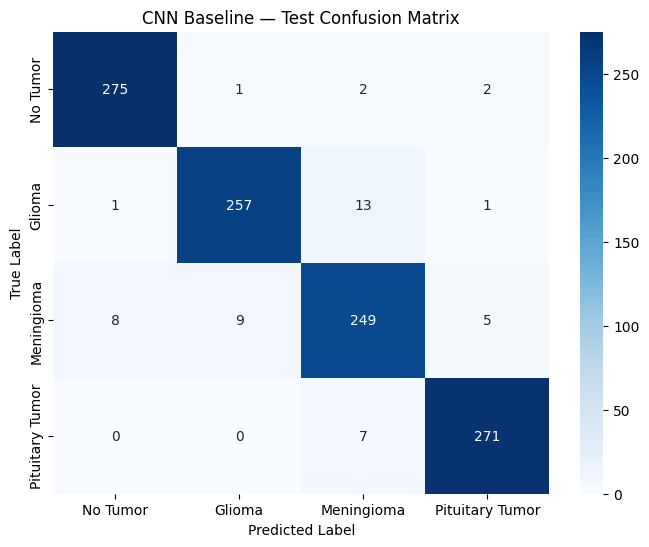

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())


cm = confusion_matrix(all_labels, all_predictions)

class_names = [
    "No Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary Tumor"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Baseline — Test Confusion Matrix")
plt.show()

In [ ]:
import imagehash
print("ImageHash is available for perceptual hashing.")

ImageHash is available for perceptual hashing.


In [ ]:
import json
import os
import torch
from sklearn.metrics import classification_report

class_names = [
    "No Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary Tumor"
]

model.eval()

test_criterion = torch.nn.CrossEntropyLoss()
test_loss_total = 0.0
test_correct = 0
test_total = 0

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = test_criterion(outputs, labels)
        predictions = torch.argmax(outputs, dim=1)

        test_loss_total += loss.item() * labels.size(0)
        test_correct += (predictions == labels).sum().item()
        test_total += labels.size(0)

        all_labels.extend(labels.cpu().tolist())
        all_predictions.extend(predictions.cpu().tolist())

test_loss = test_loss_total / test_total
test_accuracy = test_correct / test_total

report_dict = classification_report(
    all_labels,
    all_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

baseline_metrics = {
    "model": "SmallCNN",
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": 0.001,
    "best_validation_accuracy": float(best_val_accuracy),
    "best_validation_epoch": int(best_epoch),
    "final_train_accuracy": float(train_accuracies[-1]),
    "final_validation_accuracy": float(val_accuracies[-1]),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "macro_precision": float(report_dict["macro avg"]["precision"]),
    "macro_recall": float(report_dict["macro avg"]["recall"]),
    "macro_f1": float(report_dict["macro avg"]["f1-score"]),
    "weighted_precision": float(report_dict["weighted avg"]["precision"]),
    "weighted_recall": float(report_dict["weighted avg"]["recall"]),
    "weighted_f1": float(report_dict["weighted avg"]["f1-score"]),
    "class_report": report_dict,
    "class_names": class_names,
    "checkpoint": cnn_baseline_path
}

os.makedirs(RESULTS_DIR, exist_ok=True)

metrics_path = os.path.join(
    RESULTS_DIR,
    "cnn_baseline_metrics.json"
)

with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(baseline_metrics, file, indent=4)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Metrics saved to: {metrics_path}")

print(
    classification_report(
        all_labels,
        all_predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=class_names,
        zero_division=0
    )
)

Test loss: 0.3191
Test accuracy: 95.55%
Metrics saved to: /content/drive/MyDrive/BrainTumorProject/results/cnn_baseline_metrics.json
                 precision    recall  f1-score   support

       No Tumor       0.97      0.98      0.98       280
         Glioma       0.96      0.94      0.95       272
     Meningioma       0.92      0.92      0.92       271
Pituitary Tumor       0.97      0.97      0.97       278

       accuracy                           0.96      1101
      macro avg       0.96      0.96      0.96      1101
   weighted avg       0.96      0.96      0.96      1101



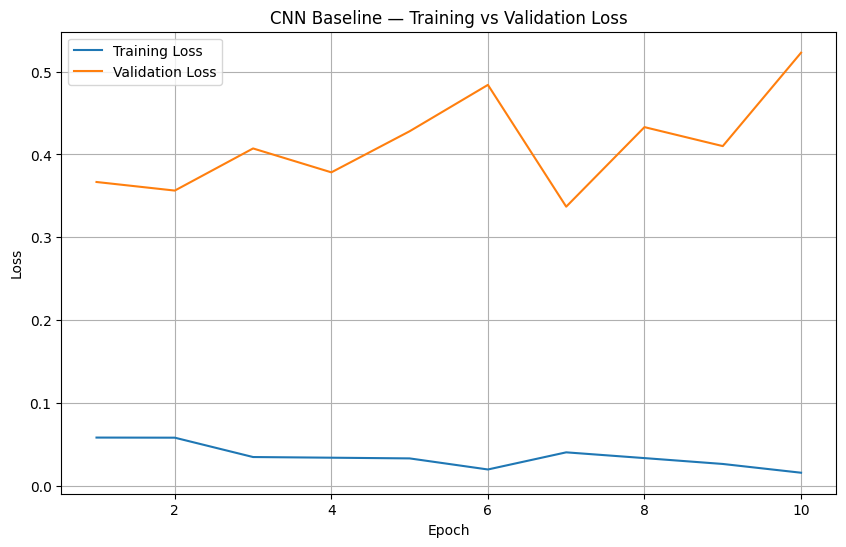

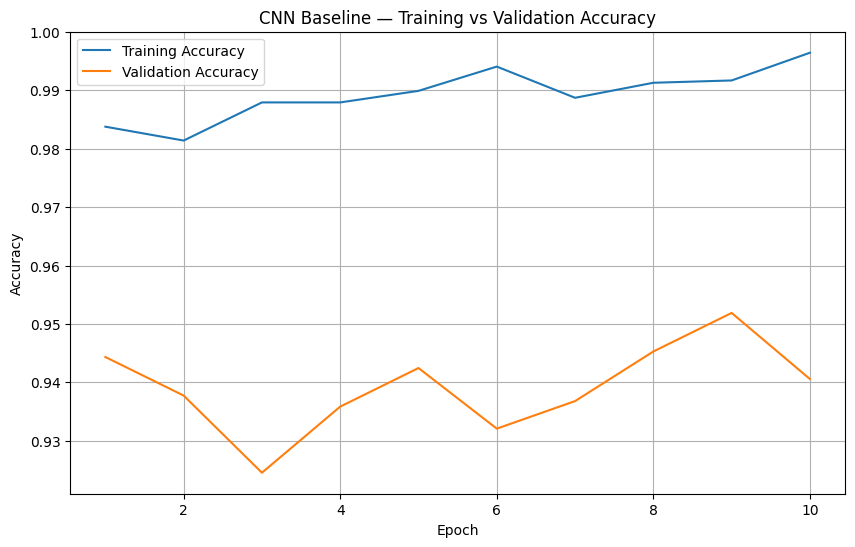

Loss curve saved to:
/content/drive/MyDrive/BrainTumorProject/results/cnn_baseline_loss.png

Accuracy curve saved to:
/content/drive/MyDrive/BrainTumorProject/results/cnn_baseline_accuracy.png


In [ ]:
import os
import matplotlib.pyplot as plt

# Training vs Validation Loss
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Baseline — Training vs Validation Loss")
plt.legend()
plt.grid(True)

loss_plot_path = os.path.join(
    RESULTS_DIR,
    "cnn_baseline_loss.png"
)

plt.savefig(loss_plot_path, dpi=200, bbox_inches="tight")
plt.show()

# Training vs Validation Accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Baseline — Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

accuracy_plot_path = os.path.join(
    RESULTS_DIR,
    "cnn_baseline_accuracy.png"
)

plt.savefig(accuracy_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Loss curve saved to:")
print(loss_plot_path)

print("\nAccuracy curve saved to:")
print(accuracy_plot_path)

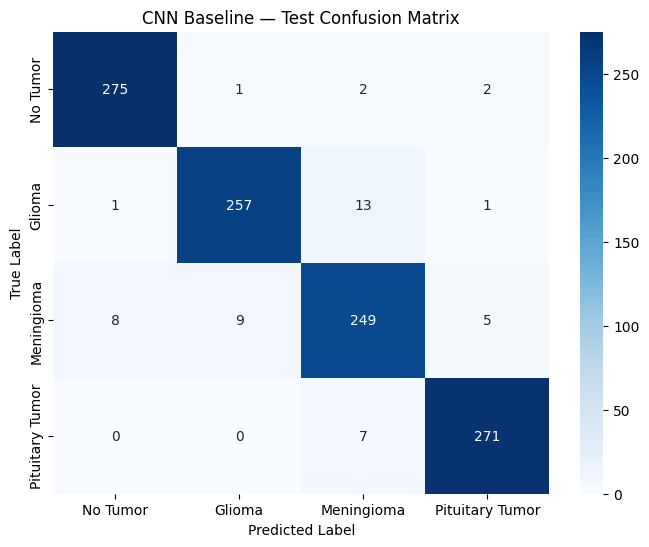

Confusion matrix saved to:
/content/drive/MyDrive/BrainTumorProject/results/cnn_baseline_confusion_matrix.png


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

cm_plot_path = os.path.join(
    RESULTS_DIR,
    "cnn_baseline_confusion_matrix.png"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Baseline — Test Confusion Matrix")

plt.savefig(
    cm_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:")
print(cm_plot_path)

In [ ]:
import os

report_path = os.path.join(
    RESULTS_DIR,
    "cnn_baseline_classification_report.txt"
)

with open(report_path, "w") as f:
    f.write("CNN Baseline — Test Classification Report\n")
    f.write("=" * 55 + "\n\n")
    f.write(report)

print("Classification report saved to:")
print(report_path)

Classification report saved to:
/content/drive/MyDrive/BrainTumorProject/results/cnn_baseline_classification_report.txt


In [ ]:
import os

phase3_summary_path = os.path.join(
    RESULTS_DIR,
    "phase_3_cnn_baseline_summary.txt"
)

summary_text = f"""
PHASE 3 — SMALL CNN BASELINE
========================================

Model
-----
SmallCNN

Input
-----
3 × 224 × 224

Classes
-------
0 → No Tumor
1 → Glioma
2 → Meningioma
3 → Pituitary Tumor

Training Configuration
----------------------
Epochs: {NUM_EPOCHS}
Batch Size: {BATCH_SIZE}
Optimizer: Adam
Learning Rate: 0.001
Loss Function: CrossEntropyLoss

Dataset
-------
Training images: 5054
Validation images: 1060
Test images: 1101

Training Results
----------------
Final Training Accuracy: {train_accuracies[-1] * 100:.2f}%
Final Validation Accuracy: {val_accuracies[-1] * 100:.2f}%

Best Validation Result
----------------------
Best Validation Accuracy: {max(val_accuracies) * 100:.2f}%
Best Epoch: {best_epoch}

Test Results
------------
Test Loss: {test_loss:.4f}
Test Accuracy: {test_accuracy * 100:.2f}%

Classification Metrics
----------------------
Macro Precision: 0.9358
Macro Recall: 0.9341
Macro F1: 0.9341

Weighted Precision: 0.9361
Weighted Recall: 0.9346
Weighted F1: 0.9346

Class-wise F1 Scores
--------------------
No Tumor: 0.9539
Glioma: 0.9189
Meningioma: 0.8833
Pituitary Tumor: 0.9805

Important Observation
---------------------
The main class-level weakness is the Glioma–Meningioma distinction.
Pituitary Tumor achieved the strongest F1-score.

Checkpoint
----------
{MODEL_DIR}/cnn_baseline_final.pth

Saved Results
-------------
cnn_baseline_metrics.json
cnn_baseline_loss.png
cnn_baseline_accuracy.png
cnn_baseline_confusion_matrix.png
cnn_baseline_classification_report.txt
"""

with open(phase3_summary_path, "w") as f:
    f.write(summary_text.strip())

print("Phase 3 summary saved to:")
print(phase3_summary_path)

Phase 3 summary saved to:
/content/drive/MyDrive/BrainTumorProject/results/phase_3_cnn_baseline_summary.txt


In [ ]:
import os

phase3_summary_path = os.path.join(
    RESULTS_DIR,
    "phase_3_cnn_baseline_summary.txt"
)

macro_avg = baseline_metrics["class_report"]["macro avg"]
weighted_avg = baseline_metrics["class_report"]["weighted avg"]

summary_text = f"""
PHASE 3 - SMALL CNN BASELINE
========================================

Model
-----
SmallCNN

Input
-----
3 x 224 x 224

Classes
-------
0 -> No Tumor
1 -> Glioma
2 -> Meningioma
3 -> Pituitary Tumor

Training Configuration
----------------------
Epochs: {NUM_EPOCHS}
Batch Size: {BATCH_SIZE}
Optimizer: Adam
Learning Rate: 0.001
Loss Function: CrossEntropyLoss

Dataset
-------
Training images: {len(train_df)}
Validation images: {len(val_df)}
Test images: {len(test_df)}

Training Results
----------------
Final Training Accuracy: {train_accuracies[-1] * 100:.2f}%
Final Validation Accuracy: {val_accuracies[-1] * 100:.2f}%

Best Validation Result
----------------------
Best Validation Accuracy: {best_val_accuracy * 100:.2f}%
Best Epoch: {best_epoch}

Test Results
------------
Test Loss: {test_loss:.4f}
Test Accuracy: {test_accuracy * 100:.2f}%

Classification Metrics
----------------------
Macro Precision: {macro_avg['precision']:.4f}
Macro Recall: {macro_avg['recall']:.4f}
Macro F1: {macro_avg['f1-score']:.4f}
Weighted Precision: {weighted_avg['precision']:.4f}
Weighted Recall: {weighted_avg['recall']:.4f}
Weighted F1: {weighted_avg['f1-score']:.4f}

Checkpoint
----------
{cnn_baseline_path}

Saved Results
-------------
cnn_baseline_metrics.json
cnn_baseline_loss.png
cnn_baseline_accuracy.png
cnn_baseline_confusion_matrix.png
cnn_baseline_classification_report.txt
"""

with open(phase3_summary_path, "w", encoding="utf-8") as file:
    file.write(summary_text.strip())

print("Phase 3 summary saved to:")
print(phase3_summary_path)

Phase 3 summary saved to:
/content/drive/MyDrive/BrainTumorProject/results/phase_3_cnn_baseline_summary.txt


PHASE 3 ENDS


PHASE 4 STARTS

In [ ]:
import os
import copy
import json
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CLASS_NAMES = [
    "No Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary Tumor"
]

NUM_CLASSES = len(CLASS_NAMES)
BATCH_SIZE = 32
NUM_EPOCHS = 10

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Phase 4 setup complete.")
print("Device:", DEVICE)
print("Classes:", CLASS_NAMES)

Phase 4 setup complete.
Device: cuda
Classes: ['No Tumor', 'Glioma', 'Meningioma', 'Pituitary Tumor']


In [ ]:
# Phase 4 Cell 1: Phase 4 Initialization - Load shared infrastructure and Phase 2 artifacts
import os
import copy
import json
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

# ============================================================
# PHASE 4 — EFFICIENTNET-B0 TRANSFER LEARNING
# ============================================================

print("=" * 60)
print("PHASE 4 — EFFICIENTNET-B0 TRANSFER LEARNING INITIALIZATION")
print("=" * 60)

# Initialize shared infrastructure (can be called independently)
def setup_drive_and_paths():
    """Robust Google Drive setup and centralized path configuration."""
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive'):
            drive.mount('/content/drive')
            print("Google Drive mounted successfully.")
        else:
            print("Google Drive already mounted.")
    except ImportError:
        print("Not running in Google Colab - Drive mounting skipped.")
    
    PROJECT_ROOT = Path("/content/drive/MyDrive/BrainTumorProject")
    
    if not PROJECT_ROOT.exists():
        raise FileNotFoundError(
            f"Project root not found: {PROJECT_ROOT}\n"
            "Please ensure the BrainTumorProject directory exists in Google Drive."
        )
    
    paths = {
        'PROJECT_ROOT': PROJECT_ROOT,
        'DATASET_DIR': PROJECT_ROOT / "dataset",
        'MODEL_DIR': PROJECT_ROOT / "models",
        'RESULTS_DIR': PROJECT_ROOT / "results",
        'LOGS_DIR': PROJECT_ROOT / "logs",
    }
    
    for path_name in ['MODEL_DIR', 'RESULTS_DIR', 'LOGS_DIR']:
        paths[path_name].mkdir(parents=True, exist_ok=True)
    
    return paths

def get_class_configuration():
    """Returns standardized class configuration used across all phases."""
    CLASS_NAMES = [
        "No Tumor",
        "Glioma", 
        "Meningioma",
        "Pituitary Tumor"
    ]
    
    CLASS_MAPPING = {
        "notumor": 0,
        "glioma": 1,
        "meningioma": 2,
        "pituitary": 3
    }
    
    NUM_CLASSES = len(CLASS_NAMES)
    
    return {
        'CLASS_NAMES': CLASS_NAMES,
        'CLASS_MAPPING': CLASS_MAPPING,
        'NUM_CLASSES': NUM_CLASSES
    }

def get_device():
    """Get the appropriate device for computation."""
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize paths
PATHS = setup_drive_and_paths()

# Initialize class configuration
CLASS_CONFIG = get_class_configuration()
CLASS_NAMES = CLASS_CONFIG['CLASS_NAMES']
CLASS_MAPPING = CLASS_CONFIG['CLASS_MAPPING']
NUM_CLASSES = CLASS_CONFIG['NUM_CLASSES']

# Initialize device
DEVICE = get_device()

# Define Phase 4 specific paths
RESULTS_DIR = PATHS['RESULTS_DIR']
MODEL_DIR = PATHS['MODEL_DIR']

# ============================================================
# LOAD PHASE 2 ARTIFACTS FROM PERSISTENT STORAGE
# ============================================================

TRAIN_SPLIT_PATH = RESULTS_DIR / "train_split.csv"
VAL_SPLIT_PATH = RESULTS_DIR / "validation_split.csv"
TEST_SPLIT_PATH = RESULTS_DIR / "test_split.csv"

# Verify Phase 2 artifacts exist
for split_path, split_name in [(TRAIN_SPLIT_PATH, "train"), (VAL_SPLIT_PATH, "validation"), (TEST_SPLIT_PATH, "test")]:
    if not split_path.exists():
        raise FileNotFoundError(
            f"Phase 2 artifact not found: {split_path}\n"
            f"Please ensure Phase 2 has been completed and {split_name}_split.csv was saved."
        )

# Load Phase 2 splits
train_df = pd.read_csv(TRAIN_SPLIT_PATH)
val_df = pd.read_csv(VAL_SPLIT_PATH)
test_df = pd.read_csv(TEST_SPLIT_PATH)

# Phase 4 specific constants
BATCH_SIZE = 32
NUM_EPOCHS = 10

print("Phase 2 artifacts loaded successfully.")
print(f"Train: {len(train_df)} images")
print(f"Validation: {len(val_df)} images")
print(f"Test: {len(test_df)} images")
print(f"Device: {DEVICE}")
print(f"Classes: {NUM_CLASSES}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print("=" * 60)

In [ ]:
in_features = efficientnet.classifier[1].in_features

efficientnet.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

efficientnet = efficientnet.to(DEVICE)

print("Updated classifier:")
print(efficientnet.classifier)

Updated classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


In [ ]:
for parameter in efficientnet.features.parameters():
    parameter.requires_grad = False

for parameter in efficientnet.classifier.parameters():
    parameter.requires_grad = True

trainable_parameters = sum(
    parameter.numel()
    for parameter in efficientnet.parameters()
    if parameter.requires_grad
)

frozen_parameters = sum(
    parameter.numel()
    for parameter in efficientnet.parameters()
    if not parameter.requires_grad
)

print("Trainable parameters:", trainable_parameters)
print("Frozen parameters:", frozen_parameters)

Trainable parameters: 5124
Frozen parameters: 4007548


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        efficientnet.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Loss:", criterion)
print("Optimizer:", optimizer)
print("Scheduler:", scheduler)

Loss: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x7caf3b3f78c0>


In [ ]:
PIN_MEMORY = DEVICE.type == "cuda"
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("DataLoaders created.")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

DataLoaders created.
Training batches: 158
Validation batches: 34
Testing batches: 35


In [ ]:
def train_one_epoch(model, loader, loss_function, optimizer, device):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy


print("Training function created.")

Training function created.


In [ ]:
def validate_one_epoch(model, loader, loss_function, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.inference_mode():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = loss_function(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct_predictions += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy


print("Validation function created.")

Validation function created.


In [ ]:
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = float("-inf")
best_epoch = 0
best_model_state = None

latest_checkpoint_path = os.path.join(
    MODEL_DIR,
    "efficientnet_b0_latest.pth"
)

best_checkpoint_path = os.path.join(
    MODEL_DIR,
    "efficientnet_b0_best.pth"
)

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        efficientnet,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_accuracy = validate_one_epoch(
        efficientnet,
        val_loader,
        criterion,
        DEVICE
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(
            efficientnet.state_dict()
        )

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": efficientnet.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "val_accuracy": val_accuracy,
        "best_val_accuracy": best_val_accuracy,
        "best_epoch": best_epoch,
        "class_names": CLASS_NAMES
    }, latest_checkpoint_path)

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy * 100:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy * 100:.2f}%"
    )

assert best_model_state is not None

torch.save({
    "epoch": best_epoch,
    "model_state_dict": best_model_state,
    "best_val_accuracy": best_val_accuracy,
    "best_epoch": best_epoch,
    "class_names": CLASS_NAMES
}, best_checkpoint_path)

print("\nTraining complete.")
print("Best epoch:", best_epoch)
print("Best validation accuracy:", f"{best_val_accuracy * 100:.2f}%")
print("Best checkpoint:", best_checkpoint_path)

Epoch [1/10] | Train Loss: 0.6757 | Train Acc: 76.99% | Val Loss: 0.4425 | Val Acc: 85.38%
Epoch [2/10] | Train Loss: 0.4455 | Train Acc: 84.90% | Val Loss: 0.3705 | Val Acc: 88.11%
Epoch [3/10] | Train Loss: 0.4019 | Train Acc: 86.07% | Val Loss: 0.3453 | Val Acc: 89.43%
Epoch [4/10] | Train Loss: 0.3701 | Train Acc: 86.72% | Val Loss: 0.3452 | Val Acc: 86.98%
Epoch [5/10] | Train Loss: 0.3651 | Train Acc: 86.78% | Val Loss: 0.3271 | Val Acc: 89.06%
Epoch [6/10] | Train Loss: 0.3548 | Train Acc: 87.69% | Val Loss: 0.3089 | Val Acc: 89.53%
Epoch [7/10] | Train Loss: 0.3423 | Train Acc: 88.11% | Val Loss: 0.2967 | Val Acc: 90.28%
Epoch [8/10] | Train Loss: 0.3417 | Train Acc: 87.75% | Val Loss: 0.3045 | Val Acc: 90.09%
Epoch [9/10] | Train Loss: 0.3310 | Train Acc: 88.31% | Val Loss: 0.2995 | Val Acc: 89.81%
Epoch [10/10] | Train Loss: 0.3307 | Train Acc: 87.83% | Val Loss: 0.2966 | Val Acc: 90.09%

Training complete.
Best epoch: 7
Best validation accuracy: 90.28%
Best checkpoint: /cont

In [ ]:
efficientnet.load_state_dict(best_model_state)
efficientnet.eval()

test_loss, test_accuracy = validate_one_epoch(
    efficientnet,
    test_loader,
    criterion,
    DEVICE
)

print("EfficientNet-B0 test results")
print("-----------------------------")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

EfficientNet-B0 test results
-----------------------------
Test loss: 0.2957
Test accuracy: 89.92%


In [ ]:
efficientnet.eval()

all_labels = []
all_predictions = []

with torch.inference_mode():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = efficientnet(images)
        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().tolist())
        all_predictions.extend(predictions.cpu().tolist())

report_dict = classification_report(
    all_labels,
    all_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

print(
    classification_report(
        all_labels,
        all_predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

                 precision    recall  f1-score   support

       No Tumor       0.93      0.98      0.95       280
         Glioma       0.93      0.85      0.89       272
     Meningioma       0.83      0.82      0.83       271
Pituitary Tumor       0.91      0.94      0.92       278

       accuracy                           0.90      1101
      macro avg       0.90      0.90      0.90      1101
   weighted avg       0.90      0.90      0.90      1101



In [ ]:
efficientnet_metrics = {
    "model": "EfficientNet-B0",
    "pretrained": True,
    "feature_extractor_frozen": True,
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "optimizer": "AdamW",
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "best_epoch": int(best_epoch),
    "best_validation_accuracy": float(best_val_accuracy),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "macro_precision": float(
        report_dict["macro avg"]["precision"]
    ),
    "macro_recall": float(
        report_dict["macro avg"]["recall"]
    ),
    "macro_f1": float(
        report_dict["macro avg"]["f1-score"]
    ),
    "weighted_precision": float(
        report_dict["weighted avg"]["precision"]
    ),
    "weighted_recall": float(
        report_dict["weighted avg"]["recall"]
    ),
    "weighted_f1": float(
        report_dict["weighted avg"]["f1-score"]
    ),
    "class_report": report_dict,
    "class_names": CLASS_NAMES,
    "checkpoint": best_checkpoint_path
}

efficientnet_metrics_path = os.path.join(
    RESULTS_DIR,
    "efficientnet_b0_metrics.json"
)

with open(
    efficientnet_metrics_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        efficientnet_metrics,
        file,
        indent=4
    )

print("Metrics saved to:")
print(efficientnet_metrics_path)

Metrics saved to:
/content/drive/MyDrive/BrainTumorProject/results/efficientnet_b0_metrics.json


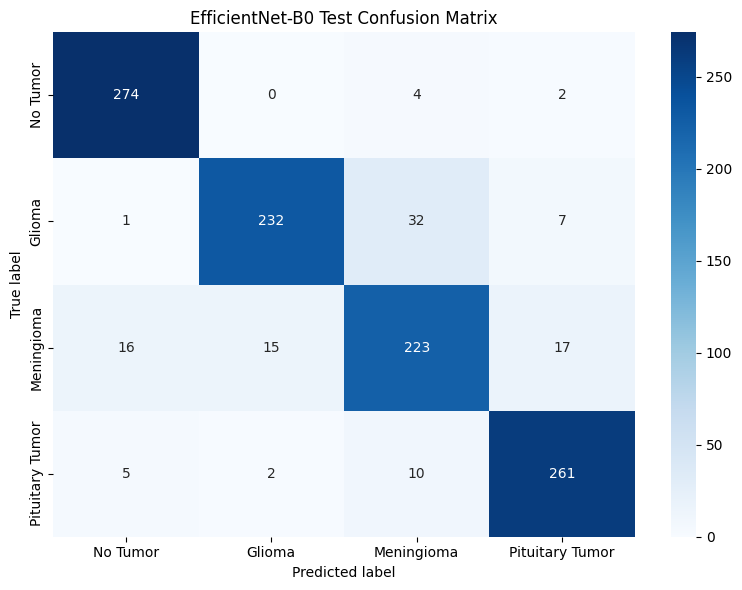

Confusion matrix saved to:
/content/drive/MyDrive/BrainTumorProject/results/efficientnet_b0_confusion_matrix.png


In [ ]:
confusion = confusion_matrix(
    all_labels,
    all_predictions,
    labels=list(range(NUM_CLASSES))
)

confusion_matrix_path = os.path.join(
    RESULTS_DIR,
    "efficientnet_b0_confusion_matrix.png"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("EfficientNet-B0 Test Confusion Matrix")
plt.tight_layout()

plt.savefig(
    confusion_matrix_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:")
print(confusion_matrix_path)

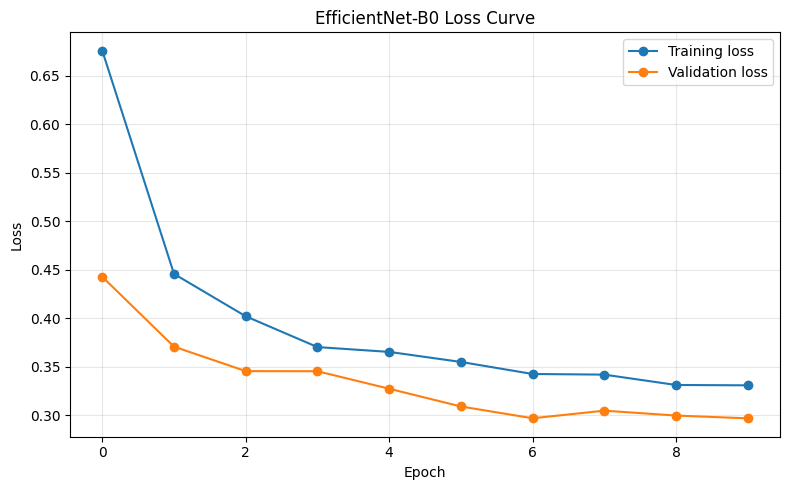

Loss curve saved to:
/content/drive/MyDrive/BrainTumorProject/results/efficientnet_b0_loss_curve.png


In [ ]:
loss_curve_path = os.path.join(
    RESULTS_DIR,
    "efficientnet_b0_loss_curve.png"
)

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training loss",
    marker="o"
)

plt.plot(
    val_losses,
    label="Validation loss",
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Loss Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    loss_curve_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Loss curve saved to:")
print(loss_curve_path)

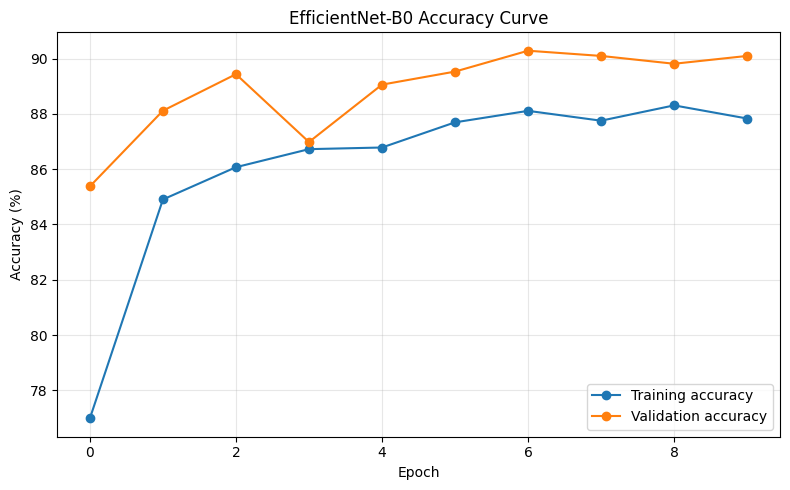

Accuracy curve saved to:
/content/drive/MyDrive/BrainTumorProject/results/efficientnet_b0_accuracy_curve.png


In [ ]:
accuracy_curve_path = os.path.join(
    RESULTS_DIR,
    "efficientnet_b0_accuracy_curve.png"
)

plt.figure(figsize=(8, 5))

plt.plot(
    [value * 100 for value in train_accuracies],
    label="Training accuracy",
    marker="o"
)

plt.plot(
    [value * 100 for value in val_accuracies],
    label="Validation accuracy",
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("EfficientNet-B0 Accuracy Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    accuracy_curve_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Accuracy curve saved to:")
print(accuracy_curve_path)

In [ ]:
phase4_summary_path = os.path.join(
    RESULTS_DIR,
    "phase_4_efficientnet_summary.txt"
)

macro_average = report_dict["macro avg"]
weighted_average = report_dict["weighted avg"]

summary_text = f"""
PHASE 4 - EFFICIENTNET-B0 TRANSFER LEARNING
============================================

Model
-----
EfficientNet-B0 with ImageNet-pretrained weights

Training configuration
----------------------
Epochs: {NUM_EPOCHS}
Batch size: {BATCH_SIZE}
Optimizer: AdamW
Learning rate: 0.001
Weight decay: 0.0001
Loss: CrossEntropyLoss
Feature extractor: Frozen
Classifier: Trainable

Dataset
-------
Training images: {len(train_df)}
Validation images: {len(val_df)}
Test images: {len(test_df)}

Results
-------
Best epoch: {best_epoch}
Best validation accuracy: {best_val_accuracy * 100:.2f}%
Test loss: {test_loss:.4f}
Test accuracy: {test_accuracy * 100:.2f}%

Macro metrics
-------------
Precision: {macro_average["precision"]:.4f}
Recall: {macro_average["recall"]:.4f}
F1-score: {macro_average["f1-score"]:.4f}

Weighted metrics
----------------
Precision: {weighted_average["precision"]:.4f}
Recall: {weighted_average["recall"]:.4f}
F1-score: {weighted_average["f1-score"]:.4f}

Artifacts
---------
Best checkpoint: {best_checkpoint_path}
Latest checkpoint: {latest_checkpoint_path}
Metrics: {efficientnet_metrics_path}
Confusion matrix: {confusion_matrix_path}
Loss curve: {loss_curve_path}
Accuracy curve: {accuracy_curve_path}
"""

with open(
    phase4_summary_path,
    "w",
    encoding="utf-8"
) as file:
    file.write(summary_text.strip())

print("Phase 4 summary saved to:")
print(phase4_summary_path)

Phase 4 summary saved to:
/content/drive/MyDrive/BrainTumorProject/results/phase_4_efficientnet_summary.txt


PHASE 4 ENDS

PHASE 5 STARTS


In [ ]:
# Phase 5 Cell 1: Phase 5 Initialization - Load shared infrastructure and required artifacts
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0

# ============================================================
# PHASE 5 - ROBUST EVALUATION
# ============================================================

print("=" * 60)
print("PHASE 5 - ROBUST EVALUATION INITIALIZATION")
print("=" * 60)

# Phase-local infrastructure keeps this phase independent of earlier cells.
def setup_drive_and_paths():
    """Mount Google Drive when needed and return centralized project paths."""
    try:
        from google.colab import drive
        if not os.path.exists("/content/drive"):
            drive.mount("/content/drive")
            print("Google Drive mounted successfully.")
        else:
            print("Google Drive already mounted.")
    except ImportError:
        print("Not running in Google Colab - Drive mounting skipped.")

    project_root = Path("/content/drive/MyDrive/BrainTumorProject")
    if not project_root.is_dir():
        raise FileNotFoundError(
            f"Project root not found: {project_root}. "
            "Please ensure BrainTumorProject exists in Google Drive."
        )

    paths = {
        "PROJECT_ROOT": project_root,
        "DATASET_DIR": project_root / "dataset",
        "MODEL_DIR": project_root / "models",
        "RESULTS_DIR": project_root / "results",
        "LOGS_DIR": project_root / "logs",
    }
    paths["RESULTS_DIR"].mkdir(parents=True, exist_ok=True)
    return paths

CLASS_NAMES = ["No Tumor", "Glioma", "Meningioma", "Pituitary Tumor"]
NUM_CLASSES = len(CLASS_NAMES)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PATHS = setup_drive_and_paths()
PROJECT_ROOT = PATHS["PROJECT_ROOT"]
DATASET_DIR = PATHS["DATASET_DIR"]
MODEL_DIR = PATHS["MODEL_DIR"]
RESULTS_DIR = PATHS["RESULTS_DIR"]
TEST_SPLIT_PATH = RESULTS_DIR / "test_split.csv"
BEST_CHECKPOINT_PATH = MODEL_DIR / "efficientnet_b0_best.pth"

if not TEST_SPLIT_PATH.is_file():
    raise FileNotFoundError(
        f"Phase 2 artifact not found: {TEST_SPLIT_PATH}. "
        "Please ensure test_split.csv was saved to the project results directory."
    )
if not BEST_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        f"Phase 4 artifact not found: {BEST_CHECKPOINT_PATH}. "
        "Please ensure efficientnet_b0_best.pth was saved to the project models directory."
    )

# Recreate the test dataset and loader from the persisted Phase 2 split.
test_df = pd.read_csv(TEST_SPLIT_PATH)
if "filepath" not in test_df.columns or "class_id" not in test_df.columns:
    raise ValueError(
        f"Phase 2 split must contain filepath and class_id columns: {TEST_SPLIT_PATH}"
    )

class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(row["filepath"]).convert("RGB")
        label = int(row["class_id"])
        if self.transform:
            image = self.transform(image)
        return image, label

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dataset = BrainTumorDataset(test_df, transform=test_transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# Reconstruct the Phase 4 architecture and load its persisted best checkpoint.
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
num_features = model.classifier[1].in_features
model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(num_features, NUM_CLASSES)
)
checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("Required artifacts loaded successfully.")
print(f"Test split: {TEST_SPLIT_PATH}")
print(f"Best checkpoint: {BEST_CHECKPOINT_PATH}")
print(f"Test samples: {len(test_dataset)}")
print(f"Device: {DEVICE}")
print("=" * 60)

In [ ]:
# Phase 5 Cell 3: Collect test predictions and probabilities
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm

all_labels = []
all_predictions = []
all_probabilities = []

model.eval()
with torch.inference_mode():
    for images, labels in tqdm(test_loader, desc="Processing test set"):
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = outputs.argmax(dim=1)

        # Collect on CPU in batches (faster than extend)
        all_labels.append(labels.cpu().numpy())
        all_predictions.append(predictions.cpu().numpy())
        all_probabilities.append(probabilities.cpu().numpy())

# Concatenate all batches at once (much faster than extend)
all_labels = np.concatenate(all_labels)
all_predictions = np.concatenate(all_predictions)
all_probabilities = np.concatenate(all_probabilities)

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

report_dict = classification_report(
    all_labels,
    all_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print()
print(
    classification_report(
        all_labels,
        all_predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

In [ ]:
# Phase 5 Cell 4: Confusion matrices and ROC-AUC metrics
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

confusion = confusion_matrix(
    all_labels,
    all_predictions,
    labels=list(range(NUM_CLASSES))
)

normalized_confusion = confusion.astype(float) / confusion.sum(
    axis=1,
    keepdims=True
)
normalized_confusion = np.nan_to_num(normalized_confusion)

roc_auc_scores = {}

for class_id, class_name in enumerate(CLASS_NAMES):
    binary_labels = (all_labels == class_id).astype(int)
    roc_auc_scores[class_name] = roc_auc_score(
        binary_labels,
        all_probabilities[:, class_id]
    )

macro_roc_auc = roc_auc_score(
    all_labels,
    all_probabilities,
    multi_class="ovr",
    average="macro",
    labels=list(range(NUM_CLASSES))
)

print("Confusion matrix:")
print(confusion)
print("\nPer-class ROC-AUC:")
for class_name, score in roc_auc_scores.items():
    print(f"{class_name}: {score:.4f}")
print(f"\nMacro ROC-AUC: {macro_roc_auc:.4f}")


In [ ]:
# Phase 5 Cell 5: Save confusion matrix and ROC-AUC plots
confusion_matrix_path = RESULTS_DIR / "phase_5_confusion_matrix.png"
normalized_confusion_path = RESULTS_DIR / "phase_5_normalized_confusion_matrix.png"
roc_auc_path = RESULTS_DIR / "phase_5_roc_auc.png"

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Phase 5 - EfficientNet-B0 Confusion Matrix")
plt.tight_layout()
plt.savefig(confusion_matrix_path, dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(
    normalized_confusion,
    annot=True,
    fmt=".2f",
    cmap="Oranges",
    vmin=0,
    vmax=1,
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Phase 5 - Normalized Confusion Matrix")
plt.tight_layout()
plt.savefig(normalized_confusion_path, dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
for class_id, class_name in enumerate(CLASS_NAMES):
    binary_labels = (all_labels == class_id).astype(int)
    false_positive_rate, true_positive_rate, _ = roc_curve(
        binary_labels,
        all_probabilities[:, class_id]
    )
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{class_name} AUC={roc_auc_scores[class_name]:.3f}"
    )

plt.plot([0, 1], [0, 1], "--", color="gray", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Phase 5 - One-vs-Rest ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(roc_auc_path, dpi=200, bbox_inches="tight")
plt.show()

print("Plots saved successfully.")


In [ ]:
# Phase 5 Cell 6: Save misclassified images and display an error gallery
error_df = test_df.copy()
error_df["true_label"] = [CLASS_NAMES[label] for label in all_labels]
error_df["predicted_label"] = [
    CLASS_NAMES[prediction]
    for prediction in all_predictions
]
error_df["confidence"] = all_probabilities.max(axis=1)
error_df["correct"] = all_labels == all_predictions

for class_id, class_name in enumerate(CLASS_NAMES):
    column_name = class_name.lower().replace(" ", "_")
    error_df[f"probability_{column_name}"] = all_probabilities[:, class_id]

misclassified_df = error_df[
    ~error_df["correct"]
].sort_values(
    by="confidence",
    ascending=False
).reset_index(drop=True)

misclassified_path = RESULTS_DIR / "phase_5_misclassified_images.csv"
error_df.to_csv(
    RESULTS_DIR / "phase_5_all_test_predictions.csv",
    index=False
)
misclassified_df.to_csv(misclassified_path, index=False)

number_to_display = min(12, len(misclassified_df))

if number_to_display > 0:
    columns = 4
    rows = int(np.ceil(number_to_display / columns))
    plt.figure(figsize=(16, 4 * rows))

    for plot_index in range(number_to_display):
        row = misclassified_df.iloc[plot_index]
        image = Image.open(row["filepath"]).convert("RGB")

        plt.subplot(rows, columns, plot_index + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(
            f"True: {row['true_label']}\n"
            f"Predicted: {row['predicted_label']}\n"
            f"Confidence: {row['confidence']:.2%}",
            fontsize=9
        )

    plt.suptitle(
        "Phase 5 - Highest-Confidence Misclassifications",
        fontsize=15
    )
    plt.tight_layout()
    gallery_path = RESULTS_DIR / "phase_5_misclassified_gallery.png"
    plt.savefig(gallery_path, dpi=200, bbox_inches="tight")
    plt.show()
else:
    gallery_path = None
    print("No misclassified images were found.")

print("Misclassified images:", len(misclassified_df))
print("Saved:", misclassified_path)


In [ ]:
# Phase 5 Cell 7: Save complete metrics and the written summary
macro_metrics = report_dict["macro avg"]
weighted_metrics = report_dict["weighted avg"]

phase5_metrics = {
    "phase": 5,
    "model": "EfficientNet-B0",
    "test_samples": int(len(all_labels)),
    "test_accuracy": float(test_accuracy),
    "macro_precision": float(macro_metrics["precision"]),
    "macro_recall": float(macro_metrics["recall"]),
    "macro_f1": float(macro_metrics["f1-score"]),
    "weighted_precision": float(weighted_metrics["precision"]),
    "weighted_recall": float(weighted_metrics["recall"]),
    "weighted_f1": float(weighted_metrics["f1-score"]),
    "macro_roc_auc": float(macro_roc_auc),
    "per_class_roc_auc": {
        name: float(score)
        for name, score in roc_auc_scores.items()
    },
    "classification_report": report_dict,
    "confusion_matrix": confusion.tolist(),
    "class_names": CLASS_NAMES,
    "checkpoint": str(BEST_CHECKPOINT_PATH),
    "confusion_matrix_plot": str(confusion_matrix_path),
    "normalized_confusion_matrix_plot": str(normalized_confusion_path),
    "roc_auc_plot": str(roc_auc_path),
    "misclassified_images": str(misclassified_path)
}

metrics_path = RESULTS_DIR / "phase_5_robust_evaluation_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(phase5_metrics, file, indent=4)

summary_path = RESULTS_DIR / "phase_5_robust_evaluation_summary.txt"
summary = f"""PHASE 5 - ROBUST EVALUATION
===========================

Model: EfficientNet-B0
Test samples: {len(all_labels)}
Test accuracy: {test_accuracy:.4f}

Macro precision: {macro_metrics['precision']:.4f}
Macro recall: {macro_metrics['recall']:.4f}
Macro F1-score: {macro_metrics['f1-score']:.4f}

Weighted precision: {weighted_metrics['precision']:.4f}
Weighted recall: {weighted_metrics['recall']:.4f}
Weighted F1-score: {weighted_metrics['f1-score']:.4f}

Macro one-vs-rest ROC-AUC: {macro_roc_auc:.4f}

Per-class ROC-AUC:
"""

for class_name, score in roc_auc_scores.items():
    summary += f"{class_name}: {score:.4f}\n"

summary += f"""
Correct predictions: {int(error_df['correct'].sum())}
Misclassified predictions: {len(misclassified_df)}

Metrics JSON: {metrics_path}
Confusion matrix: {confusion_matrix_path}
Normalized confusion matrix: {normalized_confusion_path}
ROC-AUC plot: {roc_auc_path}
Misclassified CSV: {misclassified_path}
"""

with open(summary_path, "w", encoding="utf-8") as file:
    file.write(summary.strip())

print(summary)
print("\nMetrics saved to:", metrics_path)
print("Summary saved to:", summary_path)


PHASE 5 ENDS

PHASE 6 STARTS

## Phase 6 - Explainable AI with Grad-CAM

**Goal:** Visual explanation of prediction drivers for the selected SmallCNN model.

This phase implements Grad-CAM (Gradient-weighted Class Activation Mapping) to generate heatmaps that show which regions of the MRI image most influenced the model's prediction.

In [ ]:
# Phase 6 Cell 1: Phase 6 Initialization - Load shared infrastructure and required artifacts
import os
from pathlib import Path

import torch

# ============================================================
# PHASE 6 - EXPLAINABLE AI WITH GRAD-CAM FOR SMALLCNN
# ============================================================

print("=" * 60)
print("PHASE 6 - SMALLCNN GRAD-CAM INITIALIZATION")
print("=" * 60)

try:
    from google.colab import drive
    if not os.path.exists("/content/drive"):
        drive.mount("/content/drive")
        print("Google Drive mounted successfully.")
    else:
        print("Google Drive already mounted.")
except ImportError:
    print("Not running in Google Colab - Drive mounting skipped.")

PROJECT_ROOT = Path("/content/drive/MyDrive/BrainTumorProject")
if not PROJECT_ROOT.is_dir():
    raise FileNotFoundError(
        f"Project root not found: {PROJECT_ROOT}. "
        "Please ensure BrainTumorProject exists in Google Drive."
    )

DATASET_DIR = PROJECT_ROOT / "dataset"
MODEL_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
TEST_SPLIT_PATH = RESULTS_DIR / "test_split.csv"
BEST_CHECKPOINT_PATH = MODEL_DIR / "cnn_baseline_best.pth"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["No Tumor", "Glioma", "Meningioma", "Pituitary Tumor"]
NUM_CLASSES = len(CLASS_NAMES)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not TEST_SPLIT_PATH.is_file():
    raise FileNotFoundError(
        f"Phase 2 artifact not found: {TEST_SPLIT_PATH}. "
        "Please ensure test_split.csv was saved to the project results directory."
    )
if not BEST_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        f"Phase 3 artifact not found: {BEST_CHECKPOINT_PATH}. "
        "Please ensure cnn_baseline_best.pth was saved to the project models directory."
    )

print("Required artifacts verified successfully.")
print(f"Test split: {TEST_SPLIT_PATH}")
print(f"Model checkpoint: {BEST_CHECKPOINT_PATH}")
print(f"Device: {DEVICE}")
print(f"Classes: {NUM_CLASSES}")
print("=" * 60)

In [ ]:
# Phase 6 Cell 2: Load the trained SmallCNN model
print(f"Loading model from: {BEST_CHECKPOINT_PATH}")

# Recreate the exact SmallCNN architecture used in Phase 3.
class SmallCNN(torch.nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.features = torch.nn.Sequential(
            torch.nn.Conv2d(3, 32, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Conv2d(32, 64, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Conv2d(64, 128, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(128 * 28 * 28, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = SmallCNN(num_classes=NUM_CLASSES).to(DEVICE)
checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

best_val_accuracy = checkpoint.get("best_val_accuracy")
if best_val_accuracy is not None:
    print(f"SmallCNN loaded successfully. Best validation accuracy: {best_val_accuracy:.4f}")
else:
    print("SmallCNN loaded successfully. Validation accuracy not available in checkpoint.")

In [ ]:
# Phase 6 Cell 3: Load test dataset for Grad-CAM visualization
import pandas as pd
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image

# Load test dataset from Phase 2 artifact
test_df = pd.read_csv(TEST_SPLIT_PATH)
print(f"Loaded test dataset with {len(test_df)} samples")

# Define the same transforms used in Phase 2/4
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create dataset class for Grad-CAM
class BrainTumorDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['filepath']
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx]['class_id'])
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Create test dataset
test_dataset = BrainTumorDataset(test_df, transform=test_transform)
print(f"Test dataset created with {len(test_dataset)} samples")

In [ ]:
# Phase 6 Cell 8: Select sample images for Grad-CAM visualization
# Map lowercase class names to CLASS_NAMES
class_name_mapping = {
    'notumor': 'No Tumor',
    'glioma': 'Glioma', 
    'meningioma': 'Meningioma',
    'pituitary': 'Pituitary Tumor'
}

# Create a mapping from numeric class_id to CLASS_NAMES index
class_id_to_index = {
    0: 0,  # notumor -> No Tumor
    1: 1,  # glioma -> Glioma
    2: 2,  # meningioma -> Meningioma
    3: 3   # pituitary -> Pituitary Tumor
}

print("Test dataframe columns:", test_df.columns.tolist())
print("Test dataframe shape:", test_df.shape)
print("\nUnique class names:", test_df['class_name'].unique())
print("Unique class IDs:", test_df['class_id'].unique())

# Select a few examples from each class
samples_per_class = 2
selected_samples = []

for class_id in sorted(test_df['class_id'].unique()):
    # Filter by class_id
    class_samples = test_df[test_df['class_id'] == class_id]
    
    # Get the class name
    class_name_lower = class_samples['class_name'].iloc[0]
    class_name_display = class_name_mapping.get(class_name_lower, class_name_lower)
    
    # Get first few samples from this class
    for i in range(min(samples_per_class, len(class_samples))):
        sample_idx = class_samples.index[i]
        selected_samples.append({
            'filepath': test_df.loc[sample_idx, 'filepath'],
            'true_class': class_id_to_index.get(class_id, class_id),
            'true_class_name': class_name_display
        })

print(f"\nSelected {len(selected_samples)} samples for Grad-CAM visualization")
for i, sample in enumerate(selected_samples):
    print(f"{i+1}. {sample['true_class_name']}: {Path(sample['filepath']).name}")

In [ ]:
# Phase 6 Cell 5: Import Grad-CAM dependencies and define Grad-CAM class
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register forward and backward hooks
        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]
    
    def __call__(self, x, class_idx=None):
        self.model.eval()
        output = self.model(x)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        
        # Zero gradients and backward pass
        self.model.zero_grad()
        output[0][class_idx].backward(retain_graph=True)
        
        # Get gradients and activations
        gradients = self.gradients[0]  # [C, H, W]
        activations = self.activations[0]  # [C, H, W]
        
        # Compute weights: global average pooling of gradients
        weights = gradients.mean(dim=(1, 2))  # [C]
        
        # Compute weighted combination of activations
        cam = (weights[:, None, None] * activations).sum(dim=0)  # [H, W]
        cam = F.relu(cam)  # ReLU to keep only positive contributions
        
        # Resize to input size
        cam = cam.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
        cam = F.interpolate(cam, size=(x.shape[2], x.shape[3]), mode='bilinear', align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()  # Fixed: added .detach()
        
        # Normalize to [0, 1]
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        
        return cam, class_idx
    
    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

print("Grad-CAM class defined successfully.")

In [ ]:
# Phase 6 Cell 6: Select target convolution layer and initialize Grad-CAM
# Use the final convolution layer before the last pooling operation in SmallCNN.
target_layer = model.features[6]

print(f"Target layer: {target_layer}")
print(f"Layer type: {type(target_layer)}")

# Initialize Grad-CAM.
grad_cam = GradCAM(model, target_layer)
print("SmallCNN Grad-CAM initialized successfully.")

In [ ]:
# Phase 6 Cell 7: Helper function to overlay Grad-CAM heatmap on image
def overlay_gradcam(image, cam, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """
    Overlay Grad-CAM heatmap on original image.
    
    Args:
        image: Original image (PIL Image or numpy array)
        cam: Grad-CAM heatmap (numpy array, values in [0, 1])
        alpha: Transparency of heatmap overlay
        colormap: OpenCV colormap to use
    
    Returns:
        overlayed_image: Image with heatmap overlay
    """
    # Convert PIL to numpy if needed
    if isinstance(image, Image.Image):
        image = np.array(image)
    
    # Ensure image is in [0, 255] range
    if image.max() <= 1.0:
        image = (image * 255).astype(np.uint8)
    
    # Resize cam to match image size
    cam_resized = cv2.resize(cam, (image.shape[1], image.shape[0]))
    
    # Apply colormap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), colormap)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Overlay heatmap on original image
    overlayed = image * (1 - alpha) + heatmap * alpha
    overlayed = np.clip(overlayed, 0, 255).astype(np.uint8)
    
    return overlayed

print("Grad-CAM overlay function defined.")

In [ ]:
# Phase 6 Cell 8: Function to generate Grad-CAM visualization for a single image
def generate_gradcam_visualization(image_path, model, grad_cam, transform, device):
    """
    Generate Grad-CAM visualization for a single image.
    
    Args:
        image_path: Path to the image file
        model: Trained model
        grad_cam: Grad-CAM instance
        transform: Image transform pipeline
        device: Device to run inference on
    
    Returns:
        original_image: Original PIL image
        overlayed_image: Image with Grad-CAM overlay
        predicted_class: Predicted class index
        confidence: Model confidence score
    """
    # Load and preprocess image
    original_image = Image.open(image_path).convert('RGB')
    input_tensor = transform(original_image).unsqueeze(0).to(device)
    
    # Get model prediction
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = F.softmax(output, dim=1)
        confidence, predicted_class = torch.max(probabilities, 1)
        confidence = confidence.item()
        predicted_class = predicted_class.item()
    
    # Generate Grad-CAM
    cam, _ = grad_cam(input_tensor, predicted_class)
    
    # Denormalize image for display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # Convert tensor back to numpy
    img_tensor = input_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    img_denormalized = img_tensor * std + mean
    img_denormalized = np.clip(img_denormalized, 0, 1)
    
    # Create overlay
    overlayed_image = overlay_gradcam(img_denormalized, cam)
    
    return original_image, overlayed_image, predicted_class, confidence

print("Grad-CAM visualization function defined.")

In [ ]:
# Phase 6 Cell 9: Generate Grad-CAM visualizations for selected samples
gradcam_results = []

print("Generating Grad-CAM visualizations...")
print(f"Number of selected samples: {len(selected_samples)}")

for i, sample in enumerate(selected_samples):
    print(f"\nProcessing {i+1}/{len(selected_samples)}: {sample['true_class_name']}")
    print(f"  Filepath: {sample['filepath']}")
    
    try:
        # Check if file exists
        if not Path(sample['filepath']).exists():
            print(f"  ERROR: File does not exist: {sample['filepath']}")
            continue
            
        original, overlayed, pred_class, confidence = generate_gradcam_visualization(
            sample['filepath'], model, grad_cam, test_transform, DEVICE
        )
        
        gradcam_results.append({
            'original': original,
            'overlayed': overlayed,
            'predicted_class': pred_class,
            'predicted_class_name': CLASS_NAMES[pred_class],
            'confidence': confidence,
            'true_class': sample['true_class'],
            'true_class_name': sample['true_class_name'],
            'filepath': sample['filepath'],
            'correct': pred_class == sample['true_class']
        })
        
        print(f"  ✓ Predicted: {CLASS_NAMES[pred_class]} (confidence: {confidence:.4f})")
        print(f"  ✓ True: {sample['true_class_name']}")
        print(f"  ✓ Correct: {pred_class == sample['true_class']}")
        
    except Exception as e:
        print(f"  ✗ Error processing image: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*60}")
print(f"Successfully generated {len(gradcam_results)} Grad-CAM visualizations out of {len(selected_samples)} samples")
print(f"{'='*60}")

if len(gradcam_results) == 0:
    print("WARNING: No visualizations were generated. Please check:")
    print("1. Whether the image files exist at the specified paths")
    print("2. Whether the model is loaded correctly")
    print("3. Whether the Grad-CAM initialization was successful")

In [ ]:
# Phase 6 Cell 12: Save individual Grad-CAM images
if len(gradcam_results) == 0:
    print("No Grad-CAM results to save. Please ensure Cell 9 generated visualizations successfully.")
else:
    gradcam_dir = RESULTS_DIR / "gradcam"
    gradcam_dir.mkdir(exist_ok=True)

    print(f"Saving individual Grad-CAM images to: {gradcam_dir}")

    for idx, result in enumerate(gradcam_results):
        # Create filename
        base_name = Path(result['filepath']).stem
        status = "correct" if result['correct'] else "incorrect"
        filename = f"{idx+1:02d}_{result['true_class_name'].replace(' ', '_')}_{status}.png"
        
        # Create a combined image
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
        
        # Original image
        ax1.imshow(result['original'])
        ax1.axis('off')
        ax1.set_title(f"Original\nTrue: {result['true_class_name']}", fontsize=12)
        
        # Grad-CAM overlay
        ax2.imshow(result['overlayed'])
        ax2.axis('off')
        ax2.set_title(
            f"Grad-CAM\nPred: {result['predicted_class_name']} ({result['confidence']:.2%})",
            fontsize=12
        )
        
        plt.tight_layout()
        
        # Save individual image
        save_path = gradcam_dir / filename
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
        
        print(f"  Saved: {filename}")

    print(f"\nTotal Grad-CAM images saved: {len(gradcam_results)}")

# Phase 6 Cell 14: Clean up Grad-CAM hooks
try:
    grad_cam.remove_hooks()
    print("Grad-CAM hooks removed successfully.")
except Exception as e:
    print(f"Note: Grad-CAM hooks may have already been removed or not initialized: {e}")

PHASE 7 STARTS

## Phase 7 - Model Robustness & Error Analysis

This phase compares the persisted CNN and EfficientNet checkpoints, reviews high-confidence errors, evaluates simple input perturbations, and saves an error-analysis report.

In [ ]:
# Phase 7 Cell 1: Independent initialization and artifact loading
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0

print("=" * 60)
print("PHASE 7 - MODEL ROBUSTNESS & ERROR ANALYSIS")
print("=" * 60)

try:
    from google.colab import drive
    if not os.path.exists("/content/drive"):
        drive.mount("/content/drive")
        print("Google Drive mounted successfully.")
    else:
        print("Google Drive already mounted.")
except ImportError:
    print("Not running in Google Colab - Drive mounting skipped.")

PROJECT_ROOT = Path("/content/drive/MyDrive/BrainTumorProject")
if not PROJECT_ROOT.is_dir():
    raise FileNotFoundError(
        f"Project root not found: {PROJECT_ROOT}. "
        "Please ensure BrainTumorProject exists in Google Drive."
    )

MODEL_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
TEST_SPLIT_PATH = RESULTS_DIR / "test_split.csv"
CNN_CHECKPOINT_PATH = MODEL_DIR / "cnn_baseline_best.pth"
EFFICIENTNET_CHECKPOINT_PATH = MODEL_DIR / "efficientnet_b0_best.pth"

if not TEST_SPLIT_PATH.is_file():
    raise FileNotFoundError(f"Required test split not found: {TEST_SPLIT_PATH}")
if not CNN_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(f"Required CNN checkpoint not found: {CNN_CHECKPOINT_PATH}")
if not EFFICIENTNET_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        f"Required EfficientNet checkpoint not found: {EFFICIENTNET_CHECKPOINT_PATH}"
    )

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ["No Tumor", "Glioma", "Meningioma", "Pituitary Tumor"]
NUM_CLASSES = len(CLASS_NAMES)
BATCH_SIZE = 32
NUM_WORKERS = 0

phase7_test_df = pd.read_csv(TEST_SPLIT_PATH).reset_index(drop=True)
required_columns = {"filepath", "class_id", "class_name"}
missing_columns = required_columns.difference(phase7_test_df.columns)
if missing_columns:
    raise ValueError(
        f"Phase 7 test split is missing columns {sorted(missing_columns)}: {TEST_SPLIT_PATH}"
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Test samples: {len(phase7_test_df)}")
print(f"Device: {DEVICE}")
print(f"CNN checkpoint: {CNN_CHECKPOINT_PATH}")
print(f"EfficientNet checkpoint: {EFFICIENTNET_CHECKPOINT_PATH}")

In [ ]:
# Phase 7 Cell 2: Recreate datasets, transforms, and model architectures
class Phase7Dataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path = Path(row["filepath"])
        if not image_path.is_file():
            raise FileNotFoundError(f"Test image not found: {image_path}")
        image = Image.open(image_path).convert("RGB")
        return self.transform(image), int(row["class_id"])


def build_transform(variant="standard"):
    transform_steps = [transforms.Resize((224, 224))]
    if variant == "horizontal_flip":
        transform_steps.append(transforms.RandomHorizontalFlip(p=1.0))
    elif variant == "grayscale":
        transform_steps.extend([
            transforms.Grayscale(num_output_channels=3),
        ])
    elif variant != "standard":
        raise ValueError(f"Unknown Phase 7 transform variant: {variant}")

    transform_steps.extend([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    return transforms.Compose(transform_steps)


class SmallCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def build_efficientnet():
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(num_features, NUM_CLASSES)
    )
    return model


cnn_model = SmallCNN(num_classes=NUM_CLASSES).to(DEVICE)
efficientnet_model = build_efficientnet().to(DEVICE)

cnn_checkpoint = torch.load(CNN_CHECKPOINT_PATH, map_location=DEVICE)
efficientnet_checkpoint = torch.load(
    EFFICIENTNET_CHECKPOINT_PATH,
    map_location=DEVICE
)
cnn_model.load_state_dict(cnn_checkpoint["model_state_dict"])
efficientnet_model.load_state_dict(efficientnet_checkpoint["model_state_dict"])
cnn_model.eval()
efficientnet_model.eval()

print("Model architectures reconstructed successfully.")
print("Persisted CNN and EfficientNet checkpoints loaded successfully.")

In [ ]:
# Phase 7 Cell 3: Evaluate both models and collect per-sample error data
def evaluate_model(model, model_name, dataframe, transform_variant):
    dataset = Phase7Dataset(
        dataframe,
        transform=build_transform(transform_variant)
    )
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda"
    )

    labels = []
    predictions = []
    probabilities = []

    model.eval()
    with torch.inference_mode():
        for images, batch_labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            outputs = model(images)
            batch_probabilities = torch.softmax(outputs, dim=1)
            batch_predictions = outputs.argmax(dim=1)

            labels.extend(batch_labels.numpy().tolist())
            predictions.extend(batch_predictions.cpu().numpy().tolist())
            probabilities.extend(batch_probabilities.cpu().numpy().tolist())

    labels_array = np.asarray(labels, dtype=np.int64)
    predictions_array = np.asarray(predictions, dtype=np.int64)
    probabilities_array = np.asarray(probabilities, dtype=np.float32)

    result_df = dataframe.copy()
    result_df["model"] = model_name
    result_df["transform_variant"] = transform_variant
    result_df["true_label"] = labels_array
    result_df["true_class"] = [CLASS_NAMES[index] for index in labels_array]
    result_df["predicted_label"] = predictions_array
    result_df["predicted_class"] = [CLASS_NAMES[index] for index in predictions_array]
    result_df["confidence"] = probabilities_array.max(axis=1)
    result_df["correct"] = labels_array == predictions_array

    for class_id, class_name in enumerate(CLASS_NAMES):
        column_name = class_name.lower().replace(" ", "_")
        result_df[f"probability_{column_name}"] = probabilities_array[:, class_id]

    metrics = {
        "model": model_name,
        "transform_variant": transform_variant,
        "samples": int(len(labels_array)),
        "accuracy": float((labels_array == predictions_array).mean()),
        "classification_report": classification_report(
            labels_array,
            predictions_array,
            labels=list(range(NUM_CLASSES)),
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0
        ),
        "confusion_matrix": confusion_matrix(
            labels_array,
            predictions_array,
            labels=list(range(NUM_CLASSES))
        ).tolist()
    }
    return result_df, metrics


phase7_evaluations = []
phase7_metrics = []

for model, model_name in [
    (cnn_model, "SmallCNN"),
    (efficientnet_model, "EfficientNet-B0")
]:
    for transform_variant in ["standard", "horizontal_flip", "grayscale"]:
        print(f"Evaluating {model_name} with {transform_variant} input...")
        predictions_df, metrics = evaluate_model(
            model,
            model_name,
            phase7_test_df,
            transform_variant
        )
        phase7_evaluations.append(predictions_df)
        phase7_metrics.append(metrics)
        print(f"Accuracy: {metrics['accuracy'] * 100:.2f}%")

phase7_predictions_df = pd.concat(
    phase7_evaluations,
    ignore_index=True
)

print("Phase 7 evaluation completed for both models and all input variants.")
print(f"Prediction rows collected: {len(phase7_predictions_df)}")

In [ ]:
# Phase 7 Cell 4: Build robustness and per-class stability tables
metrics_rows = []
for metrics in phase7_metrics:
    report = metrics["classification_report"]
    metrics_rows.append({
        "model": metrics["model"],
        "transform_variant": metrics["transform_variant"],
        "accuracy": metrics["accuracy"],
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"]
    })

phase7_metrics_df = pd.DataFrame(metrics_rows)
phase7_metrics_df["accuracy_change_from_standard"] = (
    phase7_metrics_df
    .groupby("model")["accuracy"]
    .transform(lambda values: values - values.iloc[0])
)

per_class_rows = []
for metrics in phase7_metrics:
    report = metrics["classification_report"]
    for class_name in CLASS_NAMES:
        per_class_rows.append({
            "model": metrics["model"],
            "transform_variant": metrics["transform_variant"],
            "class_name": class_name,
            "precision": report[class_name]["precision"],
            "recall": report[class_name]["recall"],
            "f1_score": report[class_name]["f1-score"],
            "support": report[class_name]["support"]
        })

phase7_per_class_df = pd.DataFrame(per_class_rows)

print("Overall robustness comparison:")
display(phase7_metrics_df.round(4))
print("Per-class stability comparison:")
display(phase7_per_class_df.round(4))

In [ ]:
# Phase 7 Cell 5: Save high-confidence error tables and create an error gallery
standard_predictions = phase7_predictions_df[
    phase7_predictions_df["transform_variant"] == "standard"
].copy()

standard_errors = standard_predictions[
    ~standard_predictions["correct"]
].sort_values(
    by=["model", "confidence"],
    ascending=[True, False]
).reset_index(drop=True)

error_table_path = RESULTS_DIR / "phase_7_high_confidence_errors.csv"
standard_errors.to_csv(error_table_path, index=False)

number_to_display = min(12, len(standard_errors))
if number_to_display > 0:
    gallery_rows = int(np.ceil(number_to_display / 4))
    fig, axes = plt.subplots(
        gallery_rows,
        4,
        figsize=(16, 4 * gallery_rows),
        squeeze=False
    )
    axes = axes.flatten()

    for axis in axes:
        axis.axis("off")

    for plot_index in range(number_to_display):
        row = standard_errors.iloc[plot_index]
        image = Image.open(row["filepath"]).convert("RGB")
        axes[plot_index].imshow(image)
        axes[plot_index].set_title(
            f"{row['model']}\n"
            f"True: {row['true_class']} | Pred: {row['predicted_class']}\n"
            f"Confidence: {row['confidence']:.2%}",
            fontsize=9
        )

    fig.suptitle("Phase 7 - Highest-Confidence Standard-Input Errors")
    fig.tight_layout()
    gallery_path = RESULTS_DIR / "phase_7_error_gallery.png"
    fig.savefig(gallery_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
else:
    gallery_path = None
    print("No standard-input errors were found.")

print(f"High-confidence errors saved to: {error_table_path}")
print(f"Error gallery saved to: {gallery_path}")
print(f"Standard-input errors: {len(standard_errors)}")

In [ ]:
# Phase 7 Cell 6: Save robustness plots and tabular artifacts
metrics_csv_path = RESULTS_DIR / "phase_7_robustness_metrics.csv"
per_class_csv_path = RESULTS_DIR / "phase_7_per_class_metrics.csv"
predictions_csv_path = RESULTS_DIR / "phase_7_all_predictions.csv"

phase7_metrics_df.to_csv(metrics_csv_path, index=False)
phase7_per_class_df.to_csv(per_class_csv_path, index=False)
phase7_predictions_df.to_csv(predictions_csv_path, index=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=phase7_metrics_df,
    x="transform_variant",
    y="accuracy",
    hue="model"
)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Input variant")
plt.title("Phase 7 - Model Robustness Comparison")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
robustness_plot_path = RESULTS_DIR / "phase_7_robustness_comparison.png"
plt.savefig(robustness_plot_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close()

standard_per_class = phase7_per_class_df[
    phase7_per_class_df["transform_variant"] == "standard"
]

plt.figure(figsize=(12, 6))
sns.barplot(
    data=standard_per_class,
    x="class_name",
    y="f1_score",
    hue="model"
)
plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.xlabel("Class")
plt.title("Phase 7 - Standard-Input Per-Class F1 Comparison")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
per_class_plot_path = RESULTS_DIR / "phase_7_per_class_f1_comparison.png"
plt.savefig(per_class_plot_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close()

print(f"Robustness metrics saved to: {metrics_csv_path}")
print(f"Per-class metrics saved to: {per_class_csv_path}")
print(f"All predictions saved to: {predictions_csv_path}")
print(f"Robustness plot saved to: {robustness_plot_path}")
print(f"Per-class plot saved to: {per_class_plot_path}")

In [ ]:
# Phase 7 Cell 7: Save experiment log and error-analysis report
standard_metrics = phase7_metrics_df[
    phase7_metrics_df["transform_variant"] == "standard"
].sort_values("accuracy", ascending=False)

selected_model = standard_metrics.iloc[0]["model"]
selected_accuracy = float(standard_metrics.iloc[0]["accuracy"])

experiment_log = {
    "phase": 7,
    "purpose": "Model robustness and error analysis",
    "models": ["SmallCNN", "EfficientNet-B0"],
    "input_variants": ["standard", "horizontal_flip", "grayscale"],
    "test_split": str(TEST_SPLIT_PATH),
    "checkpoints": {
        "SmallCNN": str(CNN_CHECKPOINT_PATH),
        "EfficientNet-B0": str(EFFICIENTNET_CHECKPOINT_PATH)
    },
    "selected_model_by_standard_accuracy": selected_model,
    "selected_standard_accuracy": selected_accuracy,
    "artifacts": {
        "predictions": str(predictions_csv_path),
        "robustness_metrics": str(metrics_csv_path),
        "per_class_metrics": str(per_class_csv_path),
        "high_confidence_errors": str(error_table_path),
        "error_gallery": str(gallery_path) if gallery_path else None,
        "robustness_plot": str(robustness_plot_path),
        "per_class_plot": str(per_class_plot_path)
    }
}

experiment_log_path = RESULTS_DIR / "phase_7_experiment_log.json"
with open(experiment_log_path, "w", encoding="utf-8") as file:
    json.dump(experiment_log, file, indent=4)

report_lines = [
    "PHASE 7 - MODEL ROBUSTNESS & ERROR ANALYSIS",
    "=" * 48,
    "",
    f"Test split: {TEST_SPLIT_PATH}",
    f"Test samples: {len(phase7_test_df)}",
    "",
    "Standard-input model comparison:",
    standard_metrics[
        ["model", "accuracy", "macro_f1", "weighted_f1"]
    ].to_string(index=False),
    "",
    "Robustness results:",
    phase7_metrics_df[
        ["model", "transform_variant", "accuracy", "accuracy_change_from_standard"]
    ].to_string(index=False),
    "",
    f"Model selected by standard-input accuracy: {selected_model}",
    f"Selected standard-input accuracy: {selected_accuracy:.4f}",
    "",
    f"High-confidence standard-input errors: {len(standard_errors)}",
    f"Error table: {error_table_path}",
    f"Error gallery: {gallery_path}",
    "",
    "Interpretation:",
    "- Robustness probes are evaluation-only input perturbations.",
    "- The selected model is based on standard test accuracy only.",
    "- Confidence on an incorrect prediction is an error-analysis signal, not medical certainty.",
    ""
]

report_path = RESULTS_DIR / "phase_7_error_analysis_report.txt"
with open(report_path, "w", encoding="utf-8") as file:
    file.write("\n".join(report_lines))

print("=" * 60)
print("PHASE 7 ARTIFACTS SAVED")
print("=" * 60)
print(f"Experiment log: {experiment_log_path}")
print(f"Error-analysis report: {report_path}")
print(f"Model selected by standard accuracy: {selected_model}")
print(f"Standard accuracy: {selected_accuracy:.2%}")

PHASE 7 ENDS